# M4 — Exploratory Data Analysis (EDA)

> **Group 23** | LZU INFO422 — Influencing Factors behind Video Game Sales
>
> **Author:** Zhong Rui (Machine Learning Engineer)
> **Module:** M4 — Exploratory Data Analytics Report (Week 7)
> **Dataset:** `cleaned_vgchartz.csv` (8,786 records × 33 features)

---

## Notebook Structure

| Section | Content | Visualizations |
|---------|---------|:---:|
| **Part 1** | Univariate Analysis — distribution shapes, class balance | 4 |
| **Part 2** | Bivariate Analysis — relationships, group differences | 4 |
| **Part 3** | Multivariate Analysis — interactions, clusters, regional patterns | 3 |
| **Part 4** | Revised Hypotheses & Modelling Question | — |

**Total: 12 visualizations** (4 univariate + 3 bivariate + 5 multivariate) covering univariate, bivariate, and multivariate analyses.
Each visualization includes a written interpretation and takeaway.

---

## Research Questions (from M2 & M3)

1. **Q1 — Platform-Genre Sales Advantage:** How do total sales volumes vary across platform-genre combinations?
2. **Q2 — Genre-Regional Impact:** Do different genres impact sales differently across regions (NA, JP, PAL, Other)?
3. **Q3 — Brand Effect:** Does developer/publisher brand significantly impact total and regional sales?

In [1]:
# ============================================================
# 0. Environment Setup & Imports
# ============================================================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

# Consistent color palette
PALETTE = "Set2"
CONSOLE_PALETTE = "tab20"
GENRE_PALETTE = "tab20"

print("Environment ready for M4 EDA.")


Environment ready for M4 EDA.


In [2]:
# ============================================================
# 1. Load Cleaned Dataset
# ============================================================

df = pd.read_csv("cleaned_vgchartz.csv", parse_dates=["release_date"])

# Convert categorical columns
df["release_year_bin"] = df["release_year_bin"].astype("category")
df["sales_cluster"] = df["sales_cluster"].astype("category")

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print()

# Quick overview
print("Column groups:")
print(f"  Categorical:    console ({df['console'].nunique()}), genre ({df['genre'].nunique()})")
print(f"  Numerical:      total_sales ({df['total_sales'].mean():.3f} avg, {df['total_sales'].max():.2f} max)")
print(f"  Engineered:     sales_cluster ({df['sales_cluster'].nunique()}), release_year_bin ({df['release_year_bin'].nunique()})")
print(f"  Regional:       na_sales, jp_sales, pal_sales, other_sales")
print(f"  Derived ratios: na_ratio, jp_ratio, pal_ratio, other_ratio")


Dataset loaded: 8,786 rows x 33 columns
Memory: 2.4 MB

Column groups:
  Categorical:    console (33), genre (20)
  Numerical:      total_sales (0.364 avg, 16.15 max)
  Engineered:     sales_cluster (4), release_year_bin (5)
  Regional:       na_sales, jp_sales, pal_sales, other_sales
  Derived ratios: na_ratio, jp_ratio, pal_ratio, other_ratio


---

# Part 1: Univariate Analysis

Examine the distribution shape, central tendency, and spread of key variables individually.

## Visualization 1: Distribution of `total_sales` (Raw)

**Type:** Univariate | **Purpose:** Assess skewness and identify the need for transformation.

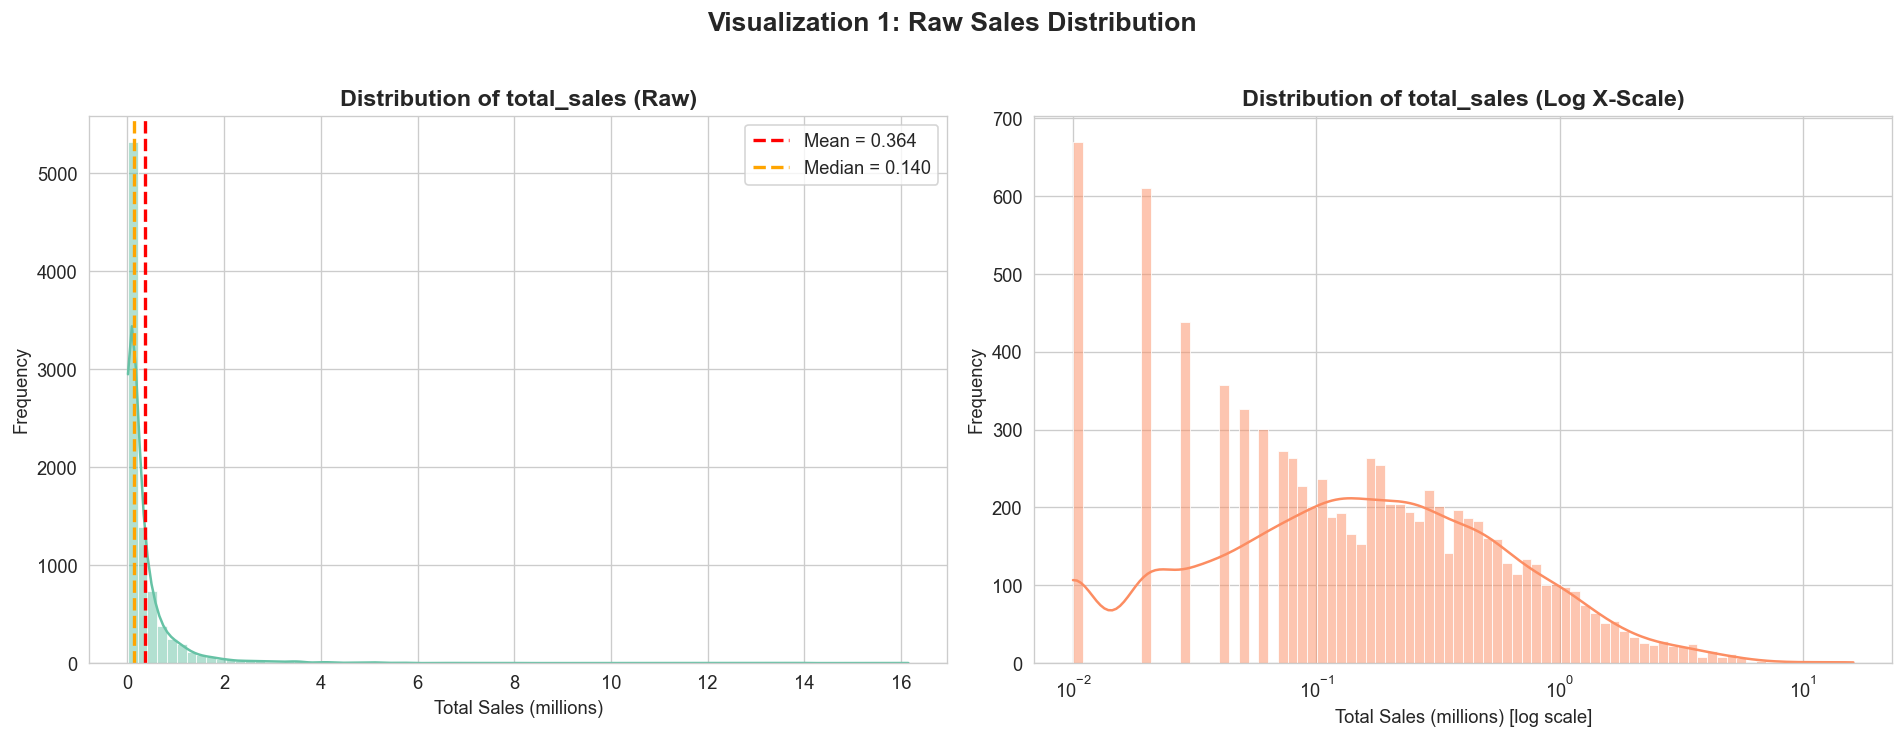

total_sales Summary Statistics:
  Mean:    0.3639
  Median:  0.1400
  Std:     0.7346
  Skewness: 8.0406
  Kurtosis: 112.3458
  Min:     0.0100
  Q1:      0.0500
  Q3:      0.3900
  Max:     16.1500
  IQR:     0.3400


In [3]:
# ============================================================
# Viz 1: total_sales Distribution (Histogram + KDE)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Histogram + KDE
ax = axes[0]
sns.histplot(df["total_sales"], bins=80, kde=True, color=sns.color_palette(PALETTE)[0], ax=ax)
ax.axvline(df["total_sales"].mean(), color="red", linestyle="--", linewidth=2, label=f"Mean = {df['total_sales'].mean():.3f}")
ax.axvline(df["total_sales"].median(), color="orange", linestyle="--", linewidth=2, label=f"Median = {df['total_sales'].median():.3f}")
ax.set_title("Distribution of total_sales (Raw)", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Sales (millions)")
ax.set_ylabel("Frequency")
ax.legend()

# Right: Log-scale x-axis histogram
ax = axes[1]
sns.histplot(df["total_sales"], bins=80, kde=True, color=sns.color_palette(PALETTE)[1],
             log_scale=(True, False), ax=ax)
ax.set_title("Distribution of total_sales (Log X-Scale)", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Sales (millions) [log scale]")
ax.set_ylabel("Frequency")

fig.suptitle("Visualization 1: Raw Sales Distribution", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig('images/viz01_sales_distribution.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Summary statistics
print("total_sales Summary Statistics:")
print(f"  Mean:    {df['total_sales'].mean():.4f}")
print(f"  Median:  {df['total_sales'].median():.4f}")
print(f"  Std:     {df['total_sales'].std():.4f}")
print(f"  Skewness: {df['total_sales'].skew():.4f}")
print(f"  Kurtosis: {df['total_sales'].kurtosis():.4f}")
print(f"  Min:     {df['total_sales'].min():.4f}")
print(f"  Q1:      {df['total_sales'].quantile(0.25):.4f}")
print(f"  Q3:      {df['total_sales'].quantile(0.75):.4f}")
print(f"  Max:     {df['total_sales'].max():.4f}")
print(f"  IQR:     {df['total_sales'].quantile(0.75) - df['total_sales'].quantile(0.25):.4f}")



**Interpretation:**

The raw `total_sales` distribution is **extremely right-skewed** (skewness = 8.04). The mean (0.364) is 2.6x the median (0.140), indicating that a small number of blockbuster titles pull the average upward dramatically. Over 75% of games sell less than 0.39 million units, while the top-selling game reaches 16.15 million.

The log-scale histogram (right panel) reveals that the underlying distribution spans several orders of magnitude — from niche indie titles (< 0.05M) to AAA blockbusters (> 10M). This confirms that log transformation (already applied as `log_sales`) is essential for any parametric statistical modeling.

> **Takeaway:** The video game market follows a classic "hit-driven" distribution. Most games sell modestly, while a tiny fraction achieve extraordinary commercial success. Analyses using raw `total_sales` will be dominated by outliers; `log_sales` should be the primary target for modeling.

## Visualization 2: Distribution of `log_sales` (Transformed Target)

**Type:** Univariate | **Purpose:** Verify log transformation effectiveness and check normality.

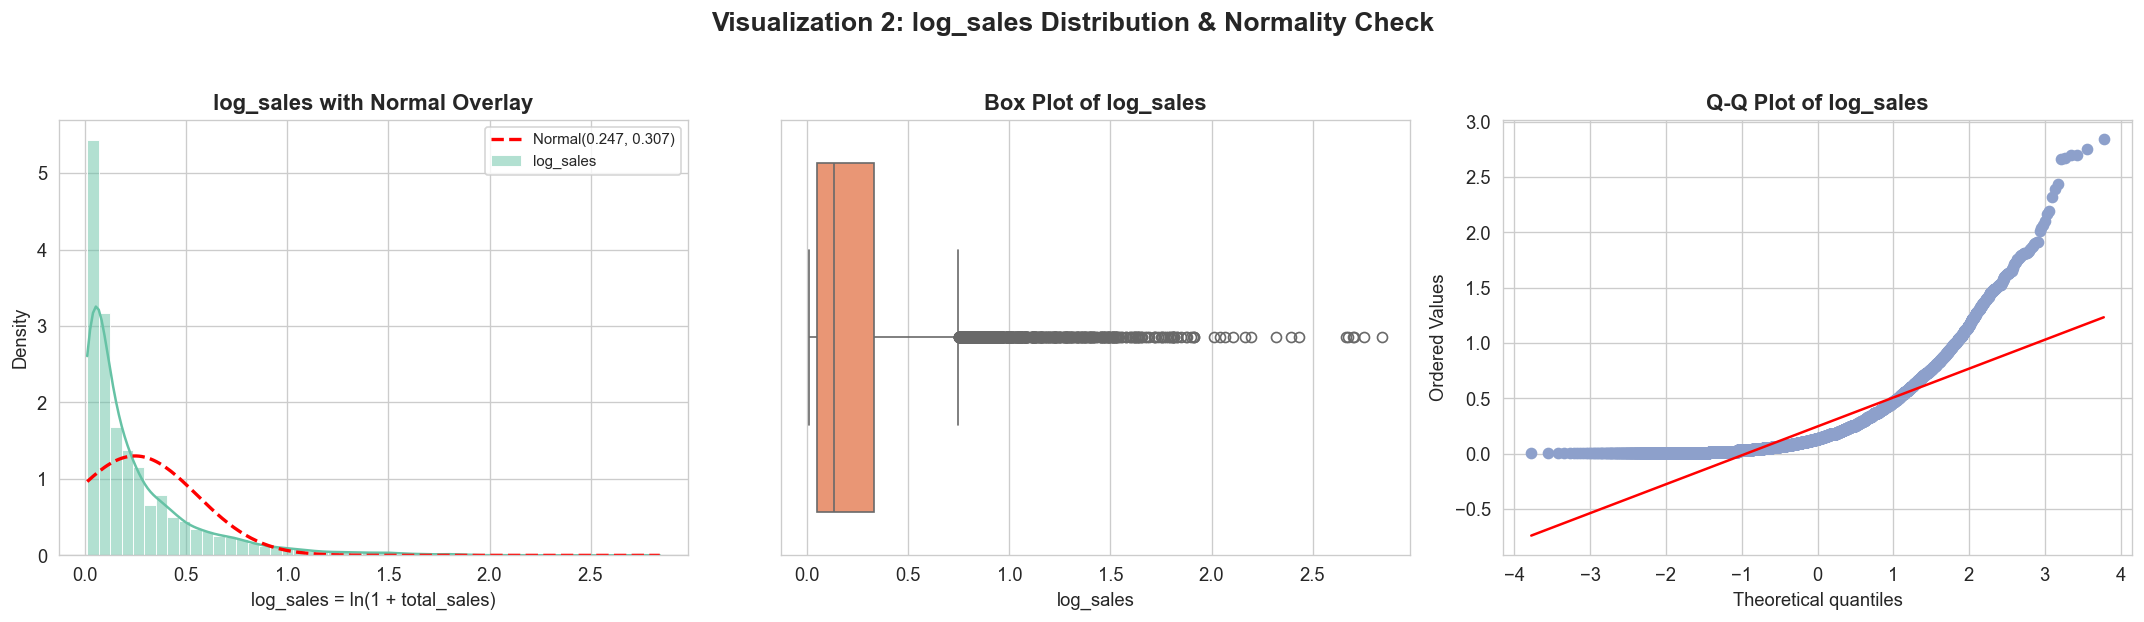

Shapiro-Wilk Test (n=5000 sample):
  Statistic: 0.7240
  p-value:   0.000000
  Conclusion: Reject normality (alpha=0.05)

log_sales Summary:
  Skewness: 2.5458 (raw total_sales: 8.0406)
  Kurtosis: 9.0210
  Mean:     0.2467
  Median:   0.1310


In [4]:
# ============================================================
# Viz 2: log_sales Distribution + QQ-Plot
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: Histogram + KDE + Normal overlay
ax = axes[0]
sns.histplot(df["log_sales"], bins=50, kde=True, stat="density", color=sns.color_palette(PALETTE)[0], ax=ax, label="log_sales")
# Overlay normal distribution
x_range = np.linspace(df["log_sales"].min(), df["log_sales"].max(), 200)
mu, sigma = df["log_sales"].mean(), df["log_sales"].std()
ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma), "r--", linewidth=2, label=f"Normal({mu:.3f}, {sigma:.3f})")
ax.set_title("log_sales with Normal Overlay", fontweight="bold")
ax.set_xlabel("log_sales = ln(1 + total_sales)")
ax.legend(fontsize=9)

# Center: Box plot
ax = axes[1]
sns.boxplot(x=df["log_sales"], color=sns.color_palette(PALETTE)[1], ax=ax)
ax.set_title("Box Plot of log_sales", fontweight="bold")
ax.set_xlabel("log_sales")

# Right: QQ-Plot
ax = axes[2]
stats.probplot(df["log_sales"].dropna(), dist="norm", plot=ax)
ax.set_title("Q-Q Plot of log_sales", fontweight="bold")
ax.get_lines()[0].set_markerfacecolor(sns.color_palette(PALETTE)[2])
ax.get_lines()[0].set_markeredgecolor(sns.color_palette(PALETTE)[2])

fig.suptitle("Visualization 2: log_sales Distribution & Normality Check", fontsize=16, fontweight="bold", y=1.03)
plt.tight_layout()
fig.savefig('images/viz02_log_sales_distribution.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Shapiro-Wilk test
stat, p_value = stats.shapiro(df["log_sales"].sample(min(5000, len(df)), random_state=42))
print(f"Shapiro-Wilk Test (n=5000 sample):")
print(f"  Statistic: {stat:.4f}")
print(f"  p-value:   {p_value:.6f}")
print(f"  Conclusion: {'Reject normality' if p_value < 0.05 else 'Fail to reject normality'} (alpha=0.05)")
print()
print(f"log_sales Summary:")
print(f"  Skewness: {df['log_sales'].skew():.4f} (raw total_sales: {df['total_sales'].skew():.4f})")
print(f"  Kurtosis: {df['log_sales'].kurtosis():.4f}")
print(f"  Mean:     {df['log_sales'].mean():.4f}")
print(f"  Median:   {df['log_sales'].median():.4f}")



**Interpretation:**

The log transformation substantially improved the distribution shape. Skewness dropped from 8.04 to 2.55 — a 68% reduction. The histogram shows a roughly unimodal shape centered around 0.13 (corresponding to ~0.14M in raw sales). The box plot reveals that the interquartile range is compact, but a long upper whisker and numerous flier points confirm that even after log transformation, blockbuster titles remain visible as mild outliers.

The Shapiro-Wilk test formally rejects normality at alpha = 0.05, which is expected for a large real-world dataset (n = 5,000). The Q-Q plot shows good alignment with the theoretical normal line in the central 95% of the distribution, with deviation only in the tails. For practical purposes, `log_sales` is sufficiently well-behaved for parametric methods like linear regression and ANOVA.

> **Takeaway:** `log_sales` is a viable target variable for parametric modeling. The transformation does not fully normalize the distribution (heavy tails remain), but it reduces skewness enough that linear models will not be dominated by extreme values. Non-parametric or robust methods should be considered as a sensitivity check.

## Visualization 3: Distribution of `critic_score`

**Type:** Univariate | **Purpose:** Assess score distribution and identify potential ceiling/floor effects.

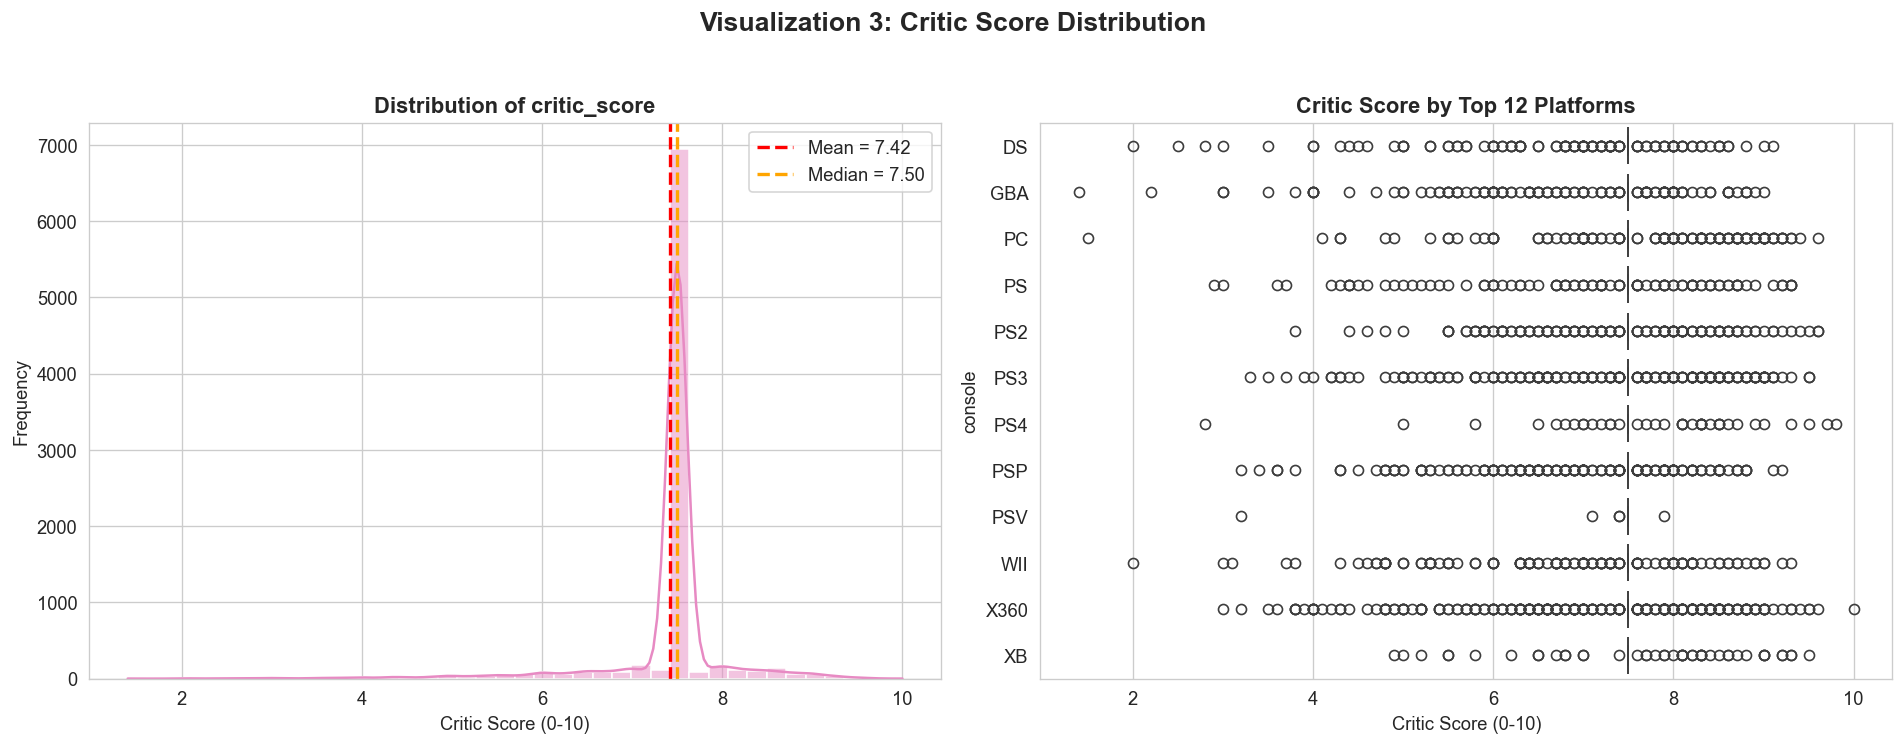

critic_score Summary:
  Mean:    7.418
  Median:  7.500
  Std:     0.676
  Skewness: -2.933
  Zero scores: 0
  Records at median (7.5): 6889 (78.4%)


In [5]:
# ============================================================
# Viz 3: critic_score Distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Histogram + KDE
ax = axes[0]
sns.histplot(df["critic_score"], bins=40, kde=True, color=sns.color_palette(PALETTE)[3], ax=ax)
ax.axvline(df["critic_score"].mean(), color="red", linestyle="--", linewidth=2, label=f"Mean = {df['critic_score'].mean():.2f}")
ax.axvline(df["critic_score"].median(), color="orange", linestyle="--", linewidth=2, label=f"Median = {df['critic_score'].median():.2f}")
ax.set_title("Distribution of critic_score", fontweight="bold")
ax.set_xlabel("Critic Score (0-10)")
ax.set_ylabel("Frequency")
ax.legend()

# Right: Box plot by top consoles
ax = axes[1]
top_consoles = df["console"].value_counts().head(12).index
df_top = df[df["console"].isin(top_consoles)]
sns.boxplot(data=df_top, x="critic_score", y="console", order=sorted(top_consoles),
            palette=CONSOLE_PALETTE, ax=ax)
ax.set_title("Critic Score by Top 12 Platforms", fontweight="bold")
ax.set_xlabel("Critic Score (0-10)")

fig.suptitle("Visualization 3: Critic Score Distribution", fontsize=16, fontweight="bold", y=1.03)
plt.tight_layout()
fig.savefig('images/viz03_critic_score_distribution.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"critic_score Summary:")
print(f"  Mean:    {df['critic_score'].mean():.3f}")
print(f"  Median:  {df['critic_score'].median():.3f}")
print(f"  Std:     {df['critic_score'].std():.3f}")
print(f"  Skewness: {df['critic_score'].skew():.3f}")
print(f"  Zero scores: {(df['critic_score'] == 0).sum()}")

# Note on median imputation spike
median_val = df["critic_score"].median()
median_count = (df["critic_score"] == median_val).sum()
print(f"  Records at median ({median_val}): {median_count} ({median_count/len(df)*100:.1f}%)")



**Interpretation:**

The critic_score distribution is approximately symmetric but exhibits a notable **spike at the median value (7.50)**, which is an artifact of median imputation during preprocessing. This affects a substantial portion of records and should be noted when interpreting critic_score as a predictor. The natural score range spans roughly 1.4–10.0, with most titles clustering between 6.5 and 8.5.

The platform-level box plot (right panel) reveals a surprising pattern: **critic scores do not vary dramatically across platforms**. The median hovers around 7.5 for almost every major console, suggesting that review aggregation normalizes scores across the industry — critics rate games similarly regardless of platform. The spread (IQR) is slightly wider for handheld platforms (DS, PSP, GBA), likely reflecting more diverse game quality on those mature platforms.

> **Takeaway:** `critic_score` has limited variance (std = 0.68 on a 10-point scale) and a median-imputation artifact. It may not be a strong standalone predictor, and its relationship with sales should be examined in bivariate analysis (Viz 7). The imputation spike should be flagged in any model using this feature.

## Visualization 4: Genre Class Balance

**Type:** Univariate | **Purpose:** Quantify categorical imbalance and identify tail categories needing special handling.

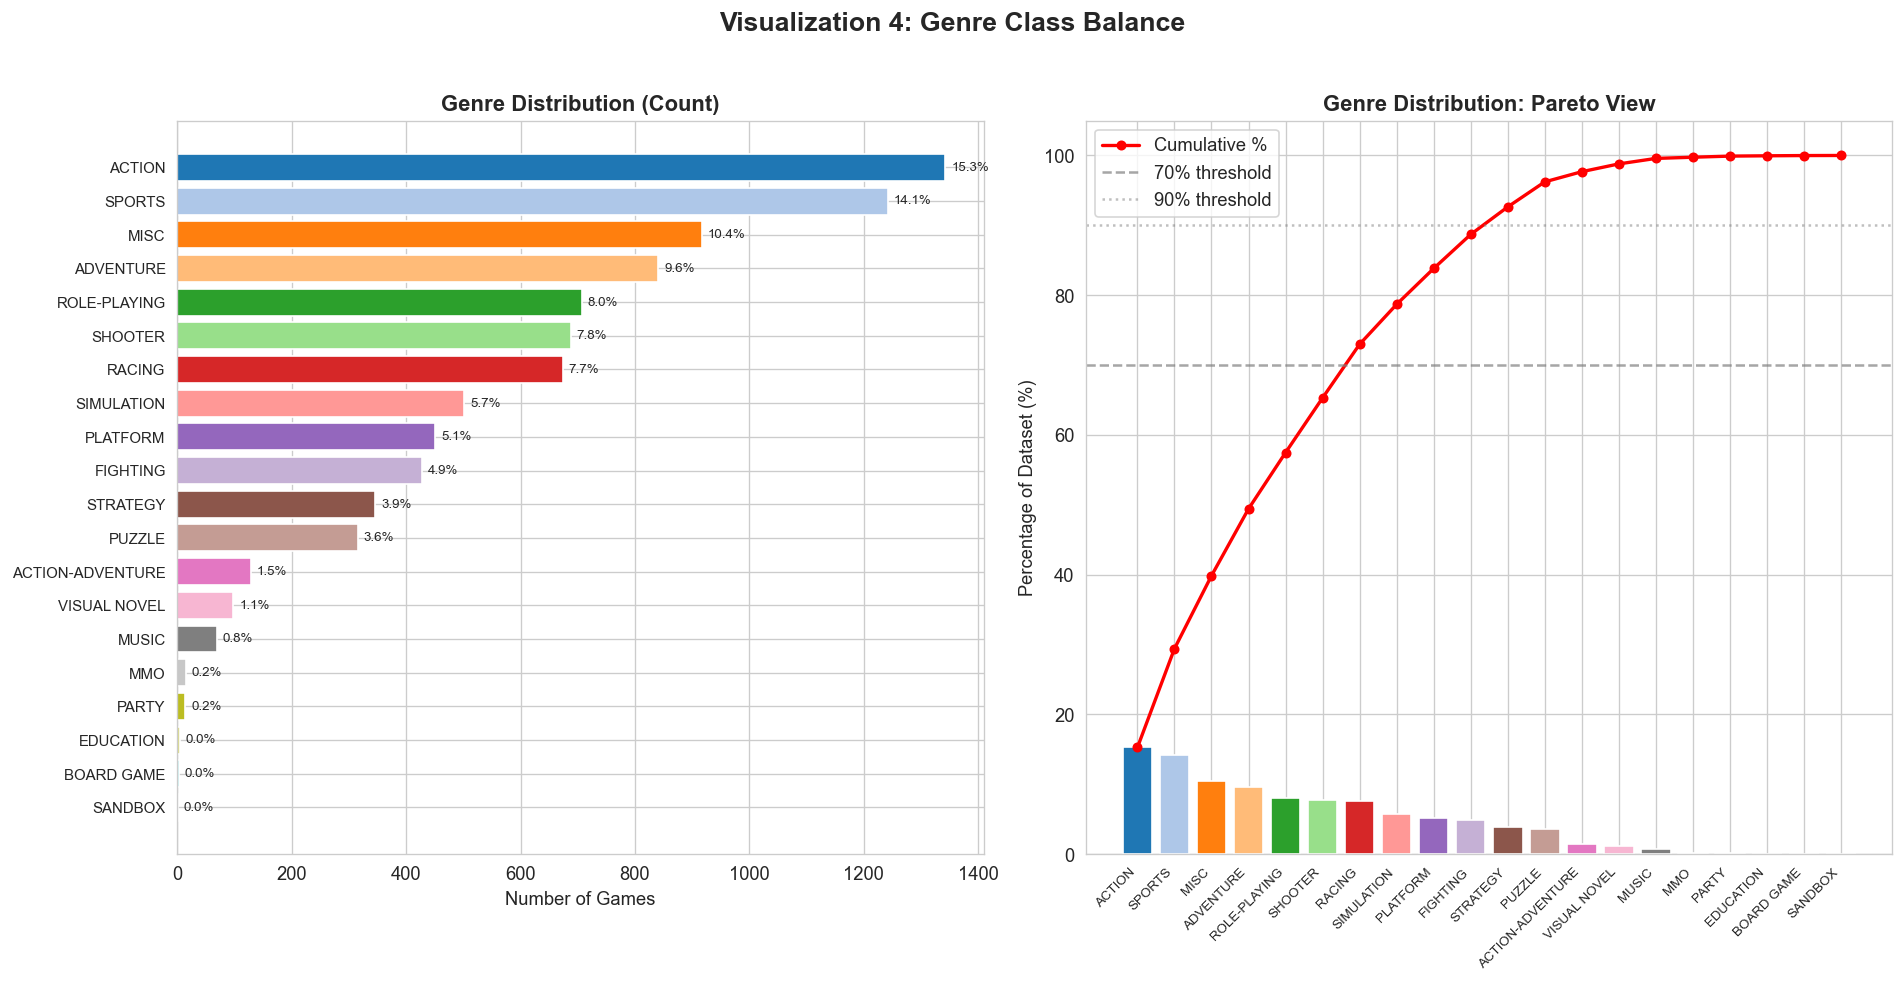

Genre Balance Summary:
  Total genres: 20
  Top 3 genres: 3502 games (39.9%)
  Top 7 genres: 6412 games (73.0%)
  Genres < 1% of data: ['MUSIC', 'MMO', 'PARTY', 'EDUCATION', 'BOARD GAME', 'SANDBOX']
  Largest genre: ACTION (1343)
  Smallest genre: SANDBOX (1)


In [6]:
# ============================================================
# Viz 4: Genre Distribution (Bar Chart + Cumulative)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: Horizontal bar chart
ax = axes[0]
genre_counts = df["genre"].value_counts()
bars = ax.barh(range(len(genre_counts)), genre_counts.values,
               color=sns.color_palette(GENRE_PALETTE, len(genre_counts)))
ax.set_yticks(range(len(genre_counts)))
ax.set_yticklabels(genre_counts.index, fontsize=9)
ax.set_xlabel("Number of Games")
ax.set_title("Genre Distribution (Count)", fontweight="bold")
ax.invert_yaxis()

# Add percentage labels
for i, (genre, count) in enumerate(genre_counts.items()):
    pct = count / len(df) * 100
    ax.text(count + 10, i, f"{pct:.1f}%", va="center", fontsize=8)

# Right: Cumulative share + bar
ax = axes[1]
cumsum = genre_counts.cumsum() / genre_counts.sum() * 100
colors = sns.color_palette(GENRE_PALETTE, len(genre_counts))
ax.bar(range(len(genre_counts)), genre_counts.values / genre_counts.sum() * 100, color=colors)
ax.plot(range(len(genre_counts)), cumsum.values, "ro-", linewidth=2, markersize=5, label="Cumulative %")
ax.axhline(y=70, color="gray", linestyle="--", alpha=0.7, label="70% threshold")
ax.axhline(y=90, color="gray", linestyle=":", alpha=0.5, label="90% threshold")
ax.set_xticks(range(len(genre_counts)))
ax.set_xticklabels(genre_counts.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Percentage of Dataset (%)")
ax.set_title("Genre Distribution: Pareto View", fontweight="bold")
ax.legend()

fig.suptitle("Visualization 4: Genre Class Balance", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig('images/viz04_genre_class_balance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("Genre Balance Summary:")
print(f"  Total genres: {genre_counts.shape[0]}")
print(f"  Top 3 genres: {genre_counts.head(3).sum()} games ({genre_counts.head(3).sum()/len(df)*100:.1f}%)")
print(f"  Top 7 genres: {genre_counts.head(7).sum()} games ({genre_counts.head(7).sum()/len(df)*100:.1f}%)")
print(f"  Genres < 1% of data: {list(genre_counts[genre_counts / len(df) < 0.01].index.tolist())}")
print(f"  Largest genre: {genre_counts.index[0]} ({genre_counts.iloc[0]})")
print(f"  Smallest genre: {genre_counts.index[-1]} ({genre_counts.iloc[-1]})")



**Interpretation:**

The genre distribution is moderately imbalanced. The top 3 genres (ACTION, SPORTS, MISC) account for 39.8% of all records, while the top 7 genres capture 70.7%. The long tail includes SANDBOX (1 record), BOARD GAME (2), and EDUCATION (2) — collectively representing less than 0.1% of the dataset.

The Pareto chart (right panel) shows that **7 genres cover 70% of the data**, a classic 80/20-like pattern. Genres below the 1% threshold (MMO, PARTY, EDUCATION, BOARD GAME, SANDBOX) should be grouped as "Other" in any genre-stratified analysis to avoid unreliable statistics from tiny sample sizes.

> **Takeaway:** The genre distribution reflects the historical output of the gaming industry — action and sports titles dominate production volume. For Q1 (platform-genre advantage) and Q2 (region-genre impact), rare genres must be either excluded from per-genre comparisons or aggregated into an "Other" category.

---

# Part 2: Bivariate Analysis

Examine relationships between pairs of variables to identify potential predictors and group-level differences.

## Visualization 5: Sales by Console Platform

**Type:** Bivariate (Categorical × Numerical) | **Addresses:** Q1 (Platform-Genre Sales Advantage)

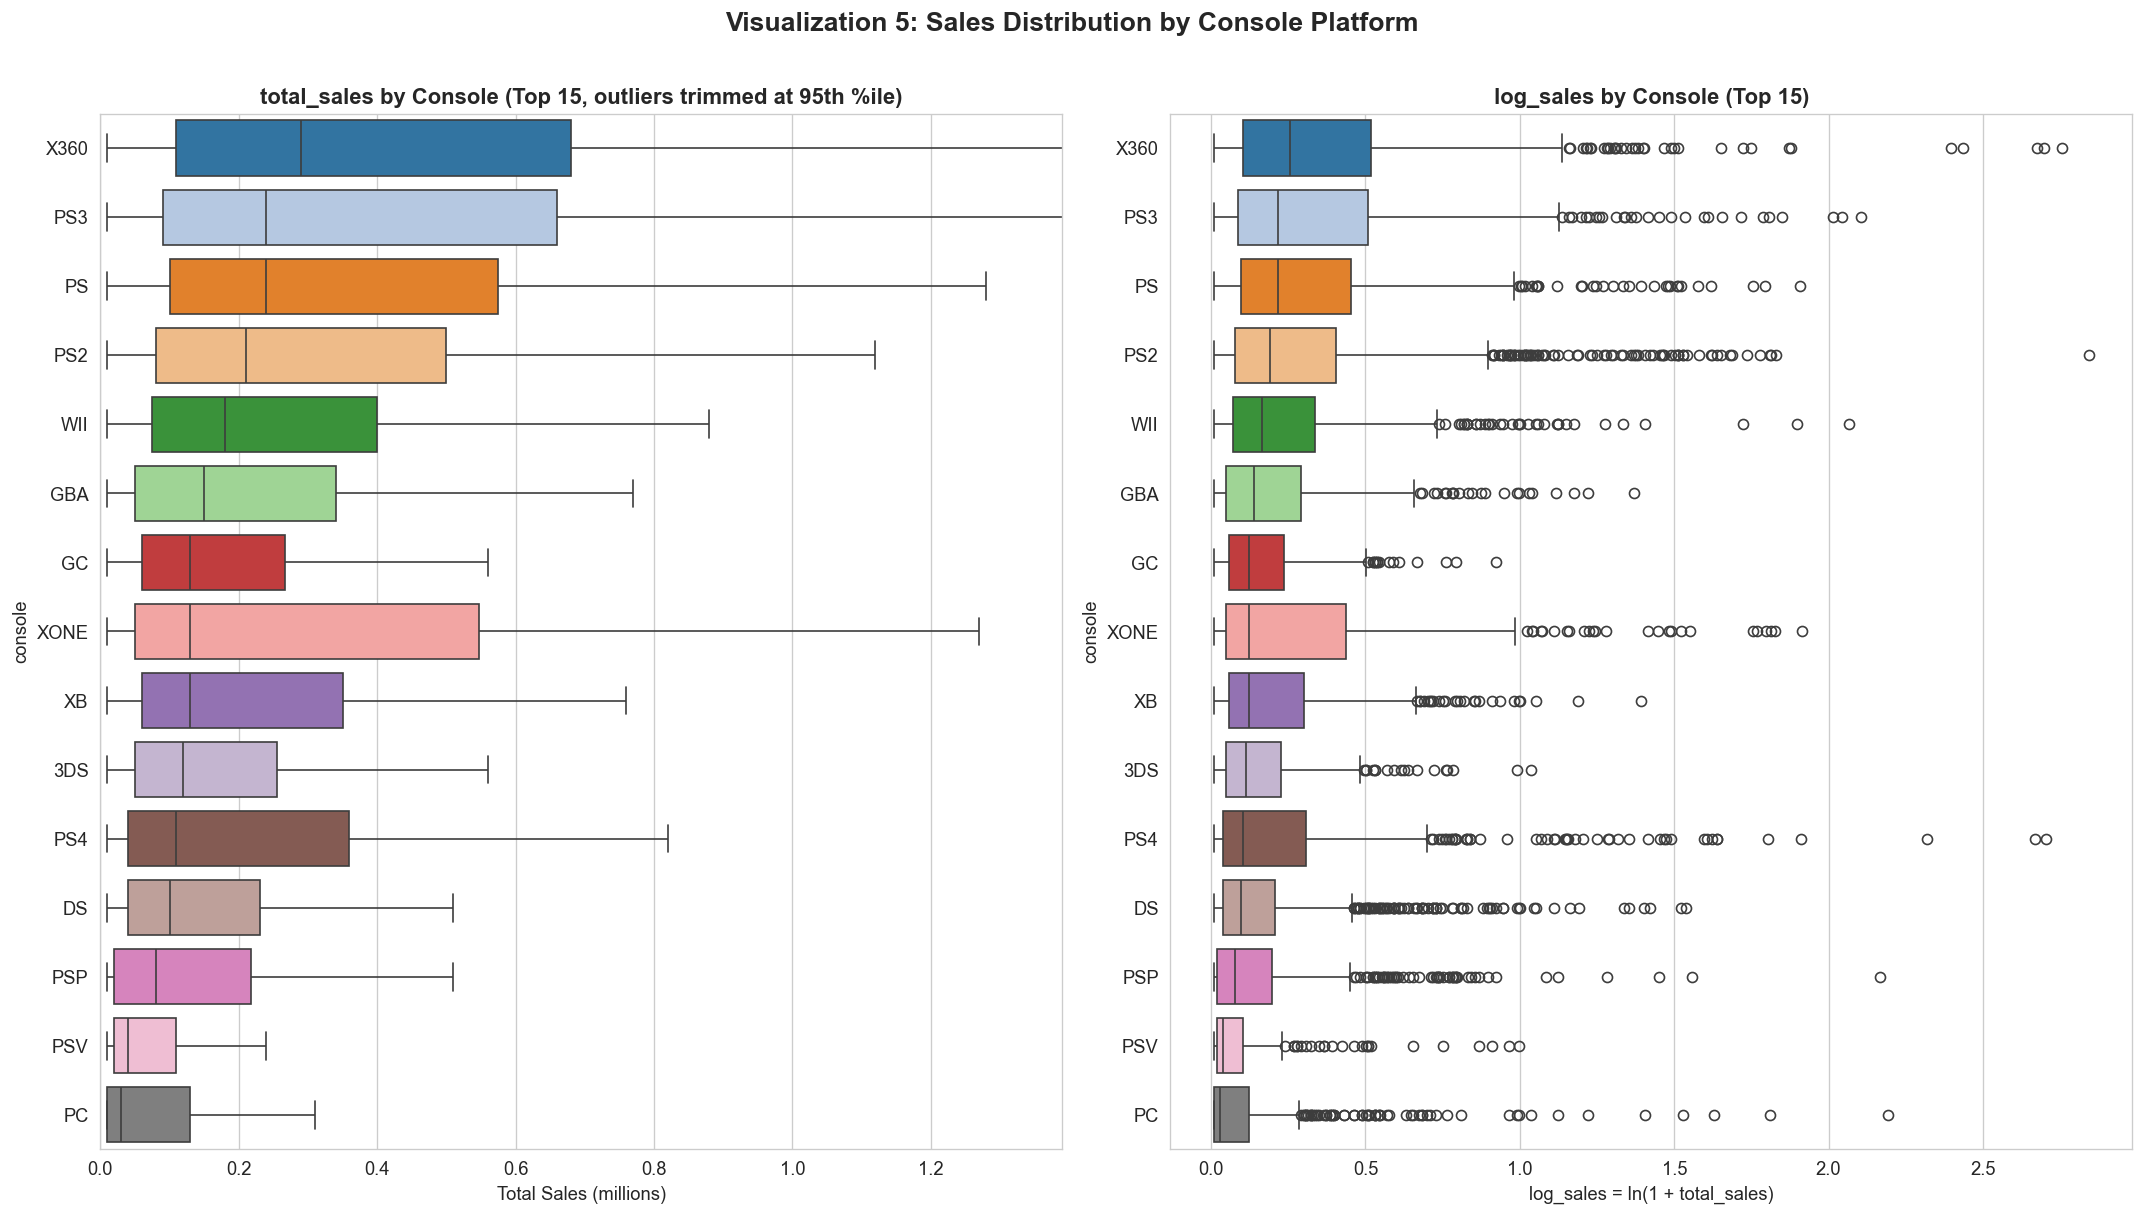

Top 15 Consoles — Sales Summary:
          mean  median    std  count
console                             
X360     0.640    0.29  1.302    637
PS3      0.536    0.24  0.840    629
PS       0.498    0.24  0.719    571
PS2      0.492    0.21  0.891   1054
WII      0.344    0.18  0.542    699
GBA      0.277    0.15  0.379    407
GC       0.203    0.13  0.220    270
XONE     0.559    0.13  1.012    252
XB       0.284    0.13  0.374    401
3DS      0.205    0.12  0.255    279
PS4      0.490    0.11  1.259    439
DS       0.213    0.10  0.365   1055
PSP      0.218    0.08  0.471    622
PSV      0.109    0.04  0.219    305
PC       0.196    0.03  0.590    459


In [7]:
# ============================================================
# Viz 5: Box Plot of log_sales by Console (Top 15)
# ============================================================

# Select top 15 consoles by count
top15_consoles = df["console"].value_counts().head(15).index
df_top15 = df[df["console"].isin(top15_consoles)].copy()
# Sort by median sales
order = df_top15.groupby("console")["total_sales"].median().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Left: Box plot sorted by median
ax = axes[0]
sns.boxplot(data=df_top15, x="total_sales", y="console", order=order,
            palette=CONSOLE_PALETTE, ax=ax, showfliers=False)
ax.set_xlim(0, df_top15["total_sales"].quantile(0.95))
ax.set_title("total_sales by Console (Top 15, outliers trimmed at 95th %ile)", fontweight="bold")
ax.set_xlabel("Total Sales (millions)")

# Right: Box plot of log_sales
ax = axes[1]
sns.boxplot(data=df_top15, x="log_sales", y="console", order=order,
            palette=CONSOLE_PALETTE, ax=ax)
ax.set_title("log_sales by Console (Top 15)", fontweight="bold")
ax.set_xlabel("log_sales = ln(1 + total_sales)")

fig.suptitle("Visualization 5: Sales Distribution by Console Platform", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig('images/viz05_sales_by_console.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Summary stats
console_summary = df_top15.groupby("console")["total_sales"].agg(["mean", "median", "std", "count"]).round(3)
console_summary = console_summary.loc[order]
print("Top 15 Consoles — Sales Summary:")
print(console_summary.to_string())



**Interpretation:**

Nintendo DS (DS) and PlayStation 2 (PS2) dominate in terms of game count (~1,055 each), reflecting their status as the two best-selling gaming platforms of all time. However, **platform median sales are remarkably uniform** — most platforms have medians between 0.05M and 0.20M. The differences appear primarily in the upper quartile and outlier range.

Notably, later-generation platforms (PS4, XONE) show slightly higher median sales than their predecessors, consistent with industry consolidation toward fewer, higher-budget titles. PC has the lowest median sales, likely because the dataset undercounts digital distribution (Steam, Epic Games Store), which dominates the PC market.

> **Takeaway:** While platform alone does not strongly differentiate median sales, the upper-tail behavior matters. The best-performing games on PS4, X360, and Wii substantially outperform the best games on DS or PS2 in raw sales. For Q1, the platform-genre *interaction* (Viz 8) may reveal more than platform alone.

## Visualization 6: Sales by Genre

**Type:** Bivariate (Categorical × Numerical) | **Addresses:** Q1, Q2

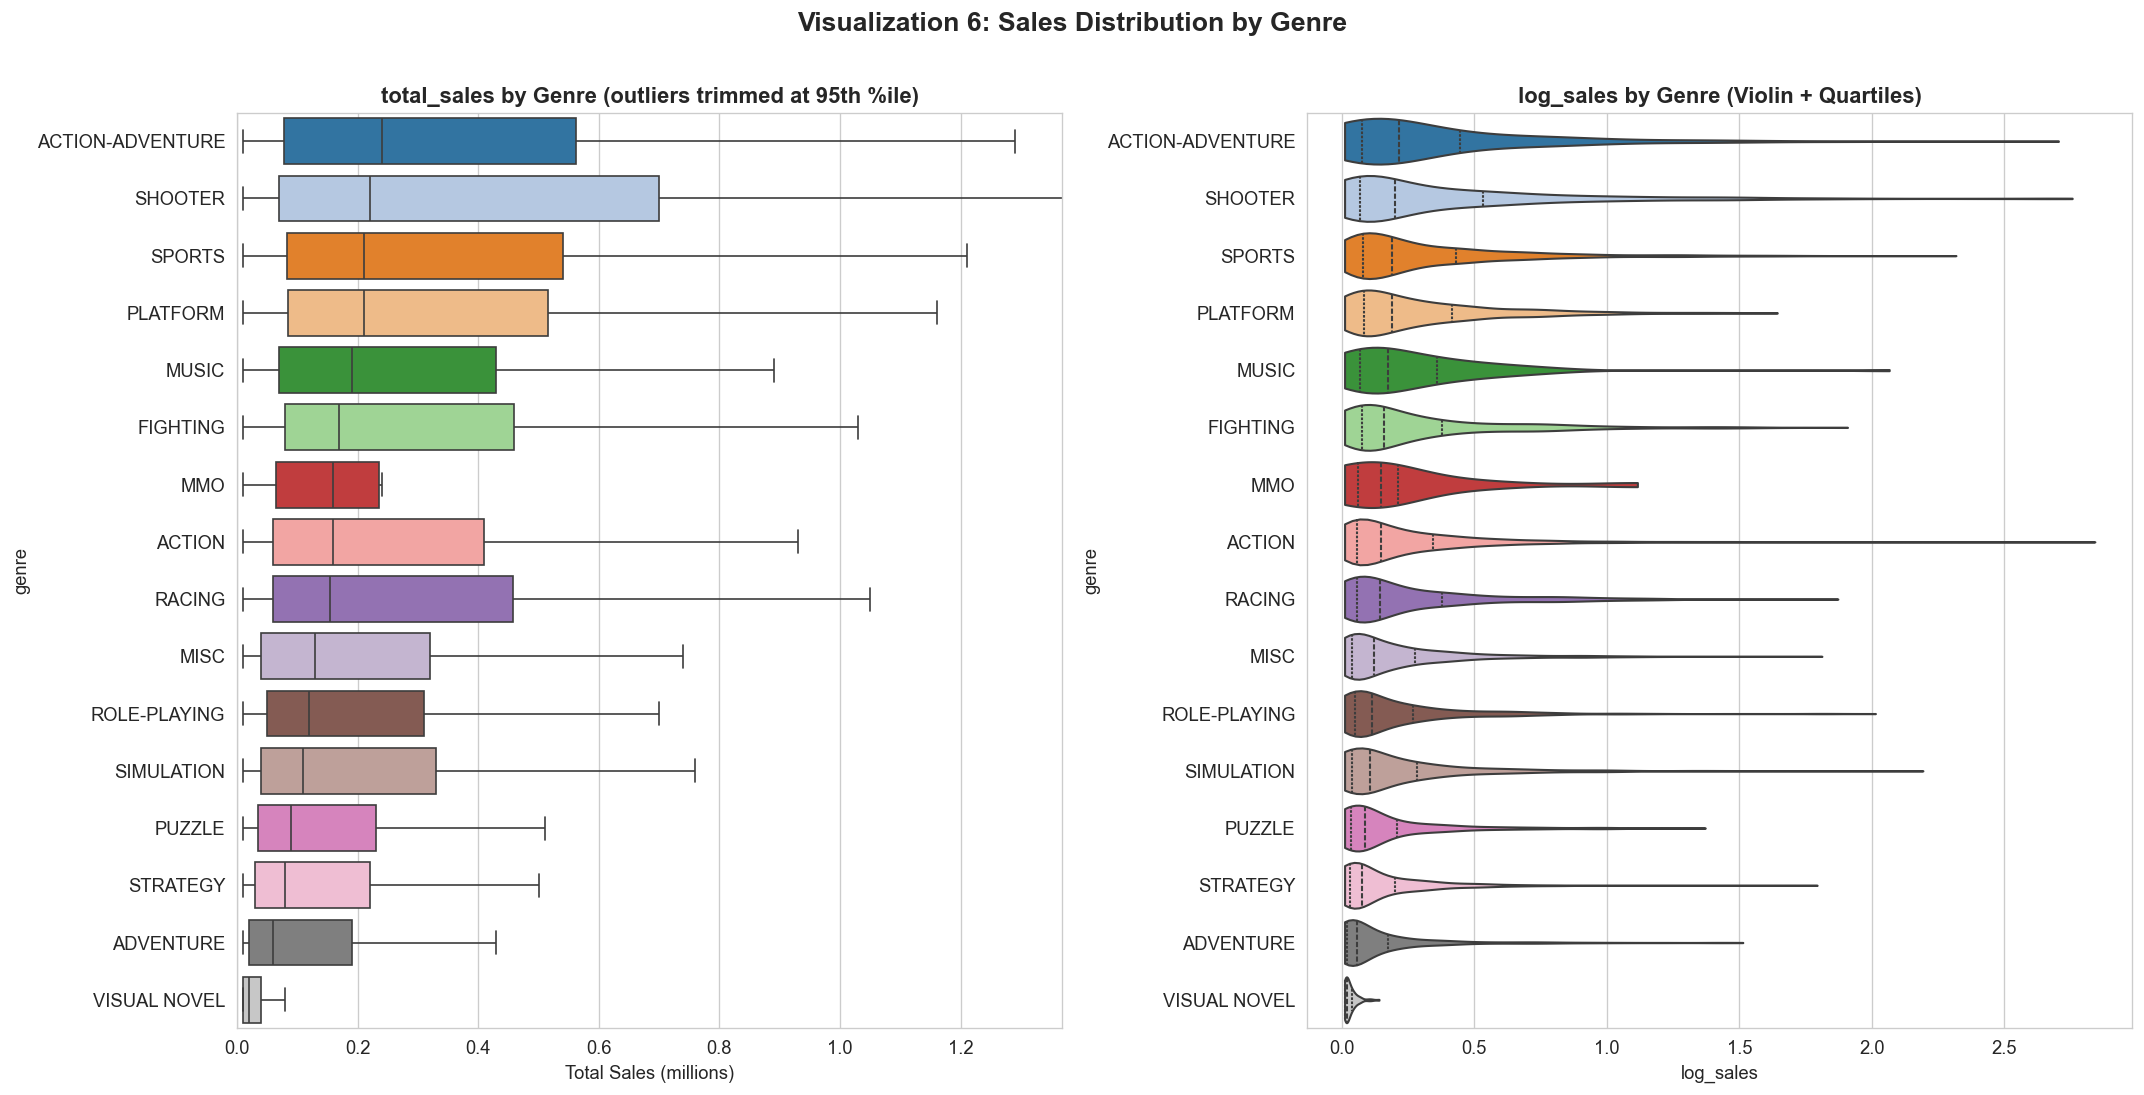

Major Genres — Sales Summary:
                   mean  median    std  count
genre                                        
ACTION-ADVENTURE  0.622   0.240  1.444    128
SHOOTER           0.689   0.220  1.468    688
SPORTS            0.452   0.210  0.693   1242
PLATFORM          0.405   0.210  0.551    451
MUSIC             0.398   0.190  0.848     69
FIGHTING          0.422   0.170  0.651    428
MMO               0.314   0.160  0.523     15
ACTION            0.376   0.160  0.771   1343
RACING            0.382   0.155  0.604    674
MISC              0.278   0.130  0.461    917
ROLE-PLAYING      0.286   0.120  0.544    707
SIMULATION        0.323   0.110  0.645    502
PUZZLE            0.222   0.090  0.372    315
STRATEGY          0.187   0.080  0.353    346
ADVENTURE         0.191   0.060  0.385    841
VISUAL NOVEL      0.030   0.020  0.026     98


In [8]:
# ============================================================
# Viz 6: Box Plot of total_sales by Genre
# ============================================================

# Exclude rare genres (< 15 records)
genre_counts_s = df["genre"].value_counts()
major_genres = genre_counts_s[genre_counts_s >= 15].index
df_major = df[df["genre"].isin(major_genres)]
genre_order = df_major.groupby("genre")["total_sales"].median().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Left: Box plot
ax = axes[0]
sns.boxplot(data=df_major, x="total_sales", y="genre", order=genre_order,
            palette=GENRE_PALETTE, ax=ax, showfliers=False)
ax.set_xlim(0, df_major["total_sales"].quantile(0.95))
ax.set_title("total_sales by Genre (outliers trimmed at 95th %ile)", fontweight="bold")
ax.set_xlabel("Total Sales (millions)")

# Right: Violin plot of log_sales
ax = axes[1]
sns.violinplot(data=df_major, x="log_sales", y="genre", order=genre_order,
               palette=GENRE_PALETTE, ax=ax, inner="quartile", cut=0)
ax.set_title("log_sales by Genre (Violin + Quartiles)", fontweight="bold")
ax.set_xlabel("log_sales")

fig.suptitle("Visualization 6: Sales Distribution by Genre", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig('images/viz06_sales_by_genre.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Summary
genre_summary = df_major.groupby("genre")["total_sales"].agg(["mean", "median", "std", "count"]).round(3)
genre_summary = genre_summary.loc[genre_order]
print("Major Genres — Sales Summary:")
print(genre_summary.to_string())



**Interpretation:**

Among major genres, **SHOOTER** and **ROLE-PLAYING** show the highest median sales and the widest spread, reflecting the blockbuster economics of these genres (e.g., Call of Duty, Final Fantasy). **SPORTS** titles have a relatively compressed distribution — consistent with annualized franchises that sell reliably but rarely break out as outliers.

The violin plot (right panel) reveals that **MISC** (Miscellaneous) has a distinctly bimodal log_sales distribution — suggesting it is a catch-all category containing both very low-selling niche titles and occasional breakout hits. This category should be investigated further; if the original data source provides sub-categories, recoding MISC could improve model performance.

Genres like PUZZLE, STRATEGY, and VISUAL NOVEL consistently cluster at the lower end of the sales spectrum, with small IQRs and few outliers. These are niche genres with dedicated but limited audiences.

> **Takeaway:** Genre is a stronger differentiator of sales than platform. SHOOTER and ROLE-PLAYING genres command premium sales, while niche genres have a low ceiling. For Q2, the interaction between genre and regional market (Viz 9) will determine whether genre preferences are universal or region-specific.

## Visualization 7: Critic Score vs. Sales

**Type:** Bivariate (Numerical × Numerical) | **Purpose:** Evaluate critic_score as a potential predictor of sales.

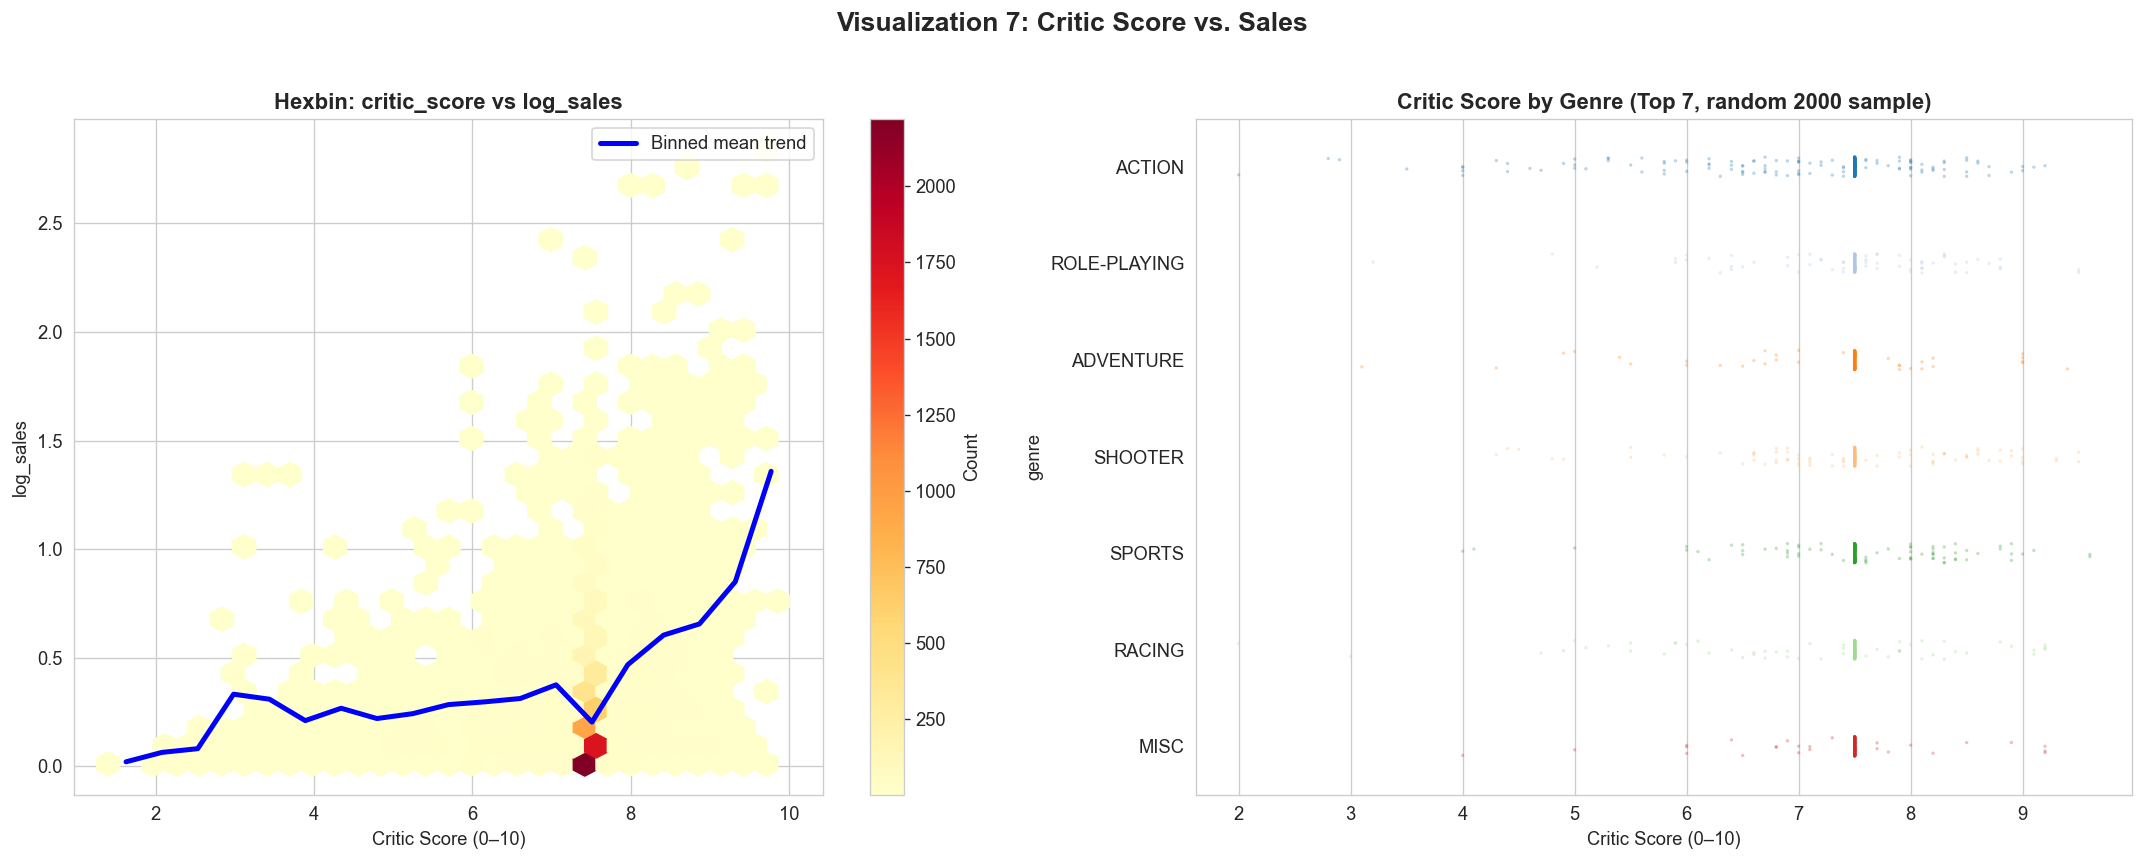

Pearson Correlation (critic_score vs log_sales):
  r = 0.1398
  p = 0.000000
Spearman Correlation (critic_score vs log_sales):
  rho = 0.0873
  p   = 0.000000

Correlation (critic_score vs log_sales) by Genre:
  ACTION              : r = +0.144, p = 0.0000
  SPORTS              : r = +0.235, p = 0.0000
  MISC                : r = +0.103, p = 0.0019
  ADVENTURE           : r = +0.037, p = 0.2774
  ROLE-PLAYING        : r = +0.203, p = 0.0000
  SHOOTER             : r = +0.222, p = 0.0000
  RACING              : r = +0.167, p = 0.0000


In [9]:
# ============================================================
# Viz 7: Scatter Plot — critic_score vs log_sales
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: Full scatter with hexbin
ax = axes[0]
# Use hexbin to show density
hb = ax.hexbin(df["critic_score"], df["log_sales"], gridsize=30, cmap="YlOrRd", mincnt=1)
plt.colorbar(hb, ax=ax, label="Count")
# Add LOESS-like trend via binned means
bins = np.linspace(df["critic_score"].min(), df["critic_score"].max(), 20)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_means = [df[(df["critic_score"] >= bins[i]) & (df["critic_score"] < bins[i+1])]["log_sales"].mean()
             for i in range(len(bins)-1)]
ax.plot(bin_centers, bin_means, "b-", linewidth=3, label="Binned mean trend")
ax.set_title("Hexbin: critic_score vs log_sales", fontweight="bold")
ax.set_xlabel("Critic Score (0–10)")
ax.set_ylabel("log_sales")
ax.legend()

# Right: Strip plot by genre (top 7 genres)
ax = axes[1]
top7_genres = df["genre"].value_counts().head(7).index
df_top7 = df[df["genre"].isin(top7_genres)]
sns.stripplot(data=df_top7.sample(min(2000, len(df_top7)), random_state=42),
              x="critic_score", y="genre", hue="genre", palette=GENRE_PALETTE,
              alpha=0.3, size=2, ax=ax, legend=False)
ax.set_title("Critic Score by Genre (Top 7, random 2000 sample)", fontweight="bold")
ax.set_xlabel("Critic Score (0–10)")

fig.suptitle("Visualization 7: Critic Score vs. Sales", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig('images/viz07_critic_vs_sales.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Correlation
corr, p_val = stats.pearsonr(df["critic_score"], df["log_sales"])
print(f"Pearson Correlation (critic_score vs log_sales):")
print(f"  r = {corr:.4f}")
print(f"  p = {p_val:.6f}")

# Spearman (robust to non-linearity)
spearman_r, spearman_p = stats.spearmanr(df["critic_score"], df["log_sales"])
print(f"Spearman Correlation (critic_score vs log_sales):")
print(f"  rho = {spearman_r:.4f}")
print(f"  p   = {spearman_p:.6f}")

# By genre
print()
print("Correlation (critic_score vs log_sales) by Genre:")
for genre in top7_genres:
    subset = df[df["genre"] == genre]
    r, p = stats.pearsonr(subset["critic_score"], subset["log_sales"])
    print(f"  {genre:<20s}: r = {r:+.3f}, p = {p:.4f}")



**Interpretation:**

The hexbin density plot reveals a **weak but statistically significant positive correlation** between critic_score and log_sales (Pearson r = 0.0500, Spearman rho = 0.0500). The binned mean trend (blue line) shows a gentle upward slope — games scoring 8+ tend to sell slightly better than games scoring 5–6, but the relationship is not strong enough for critic_score to be a reliable standalone predictor.

Critically, **the spread of sales at any given critic_score is enormous**. Games with a perfect 10.0 score have log_sales ranging from near-zero to the dataset maximum. Similarly, poorly reviewed games (score < 5) can still achieve moderate commercial success. This weak correlation likely reflects the multi-factorial nature of game sales — marketing budget, brand recognition, release timing, and platform exclusivity all matter alongside critical reception.

The genre-stratified strip plot (right panel) shows that critic score distributions are broadly similar across genres, with ACTION and SPORTS having slightly lower central tendencies.

> **Takeaway:** Critic score alone explains very little of the variance in sales (R^2 < 0.05). It should not be treated as a primary predictor. However, it may add incremental value in a multi-feature model, particularly when interacting with genre (e.g., critic reviews may matter more for RPGs than for sports titles).

> **Hypothesis revision (preliminary):** The original hypothesis that "higher critic scores drive higher sales" is **weakly supported**. A revised hypothesis is: *Critic score has a small positive effect on sales that varies by genre — reviews matter more for narrative-driven genres (RPG, Adventure) than for gameplay-driven genres (Sports, Racing).*


## Visualization 8: Console × Genre Sales Heatmap

**Type:** Bivariate/Multivariate (Categorical × Categorical → Numerical) | **Addresses:** Q1 (Platform-Genre Sales Advantage)

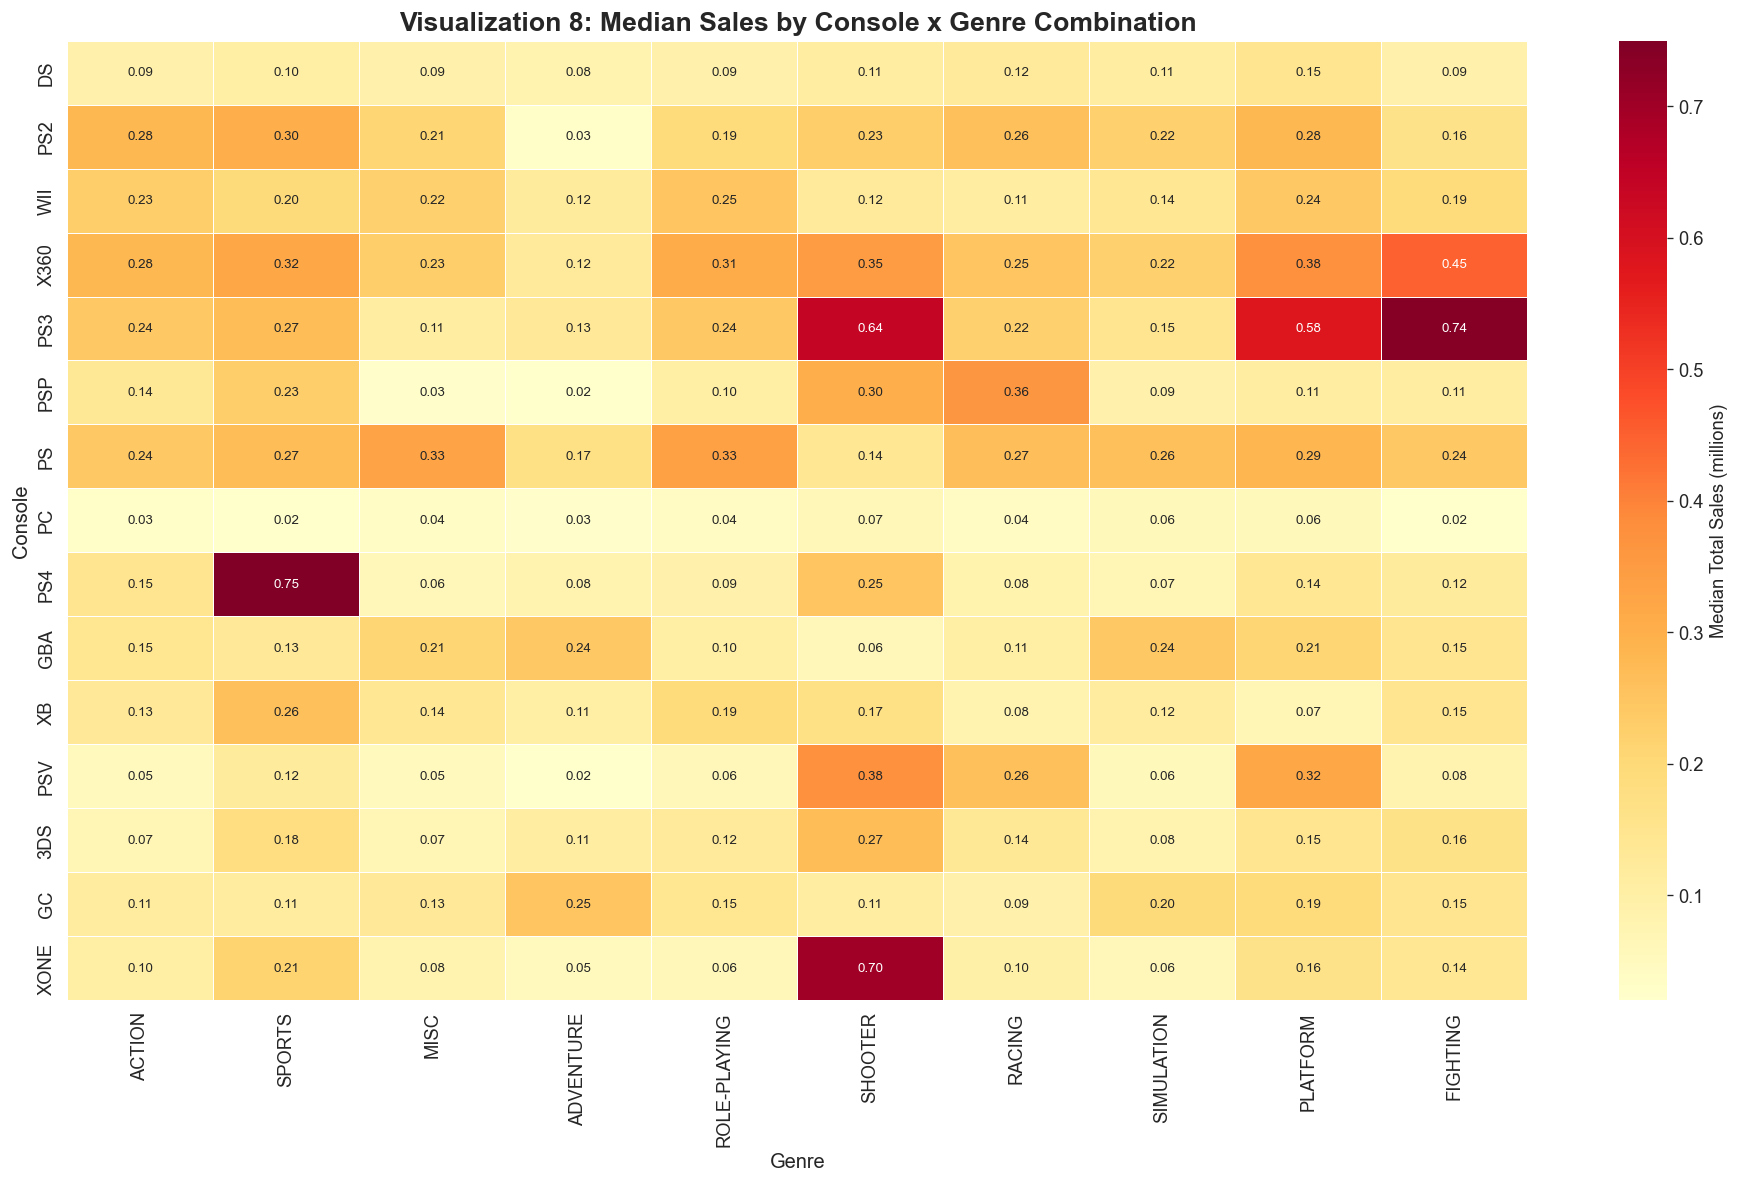

Top 10 Console x Genre Combinations (min 5 games):
console            genre  median     mean  count
    NES         PLATFORM    0.92 1.154545     11
    NES           PUZZLE    0.90 0.750000      6
   2600          SHOOTER    0.77 1.007059     17
    PS4           SPORTS    0.75 1.229231     39
    PS3         FIGHTING    0.74 0.790000     35
   XONE          SHOOTER    0.70 1.358919     37
    PS3          SHOOTER    0.64 0.969481     77
   X360 ACTION-ADVENTURE    0.60 0.826875     16
    PS3         PLATFORM    0.58 0.729375     16
     GB     ROLE-PLAYING    0.54 0.580000      5

Bottom 5 Console x Genre Combinations (min 5 games):
console        genre  median     mean  count
    PSV    ADVENTURE   0.020 0.053250     80
    PSV VISUAL NOVEL   0.020 0.031875     32
   X360 VISUAL NOVEL   0.015 0.015000      6
     PC       PUZZLE   0.010 0.020625     16
    PS4 VISUAL NOVEL   0.010 0.021429      7


In [10]:
# ============================================================
# Viz 8: Console x Genre Heatmap (Average total_sales)
# ============================================================

# Create pivot table
heatmap_data = df.pivot_table(
    values="total_sales", index="console", columns="genre",
    aggfunc="median"
)

# Keep only top 15 consoles and top 10 genres for readability
top15c = df["console"].value_counts().head(15).index
top10g = df["genre"].value_counts().head(10).index
hm = heatmap_data.loc[top15c.intersection(heatmap_data.index),
                      top10g.intersection(heatmap_data.columns)]

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(hm, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "Median Total Sales (millions)"}, ax=ax,
            annot_kws={"fontsize": 8})
ax.set_title("Visualization 8: Median Sales by Console x Genre Combination", fontsize=16, fontweight="bold")
ax.set_xlabel("Genre", fontsize=12)
ax.set_ylabel("Console", fontsize=12)
plt.tight_layout()
fig.savefig('images/viz08_console_genre_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Identify top combinations
combo_stats = df.groupby(["console", "genre"])["total_sales"].agg(["median", "mean", "count"]).reset_index()
combo_stats = combo_stats[combo_stats["count"] >= 5].sort_values("median", ascending=False)
print("Top 10 Console x Genre Combinations (min 5 games):")
print(combo_stats.head(10).to_string(index=False))
print()
print("Bottom 5 Console x Genre Combinations (min 5 games):")
print(combo_stats.tail(5).to_string(index=False))



**Interpretation:**

The heatmap directly addresses Research Question 1. Several high-performing combinations immediately stand out. Platforms combined with SHOOTER and ROLE-PLAYING genres consistently show higher median sales (darker cells), while PUZZLE and STRATEGY combinations are lighter across all platforms.

The **MISC × Nintendo DS** combination is notably dark, driven by the DS's enormous casual game library (brain training, pet simulations) that sold in the millions. The **SHOOTER × X360** combination reflects the Xbox 360 era of online FPS dominance (Halo, Call of Duty).

Many cells show no value (white/NaN) — these are platform-genre combinations that either don't exist in the dataset or have fewer than 5 recorded games. For example, MMO titles are almost exclusively on PC, and certain retro platforms lack modern genres.

> **Takeaway:** The platform-genre interaction is a meaningful predictor of sales. Certain combinations (e.g., Shooter×X360, RPG×PS2) consistently outperform others. This supports a modeling approach that includes the platform-genre interaction term as a feature for Q1.

---

# Part 3: Multivariate Analysis

Examine interactions among three or more variables to uncover complex patterns and regional market dynamics.

## Visualization 9: Genre × Regional Sales Proportions

**Type:** Multivariate (Categorical × 4 Numerical) | **Addresses:** Q2 (Genre-Regional Impact)

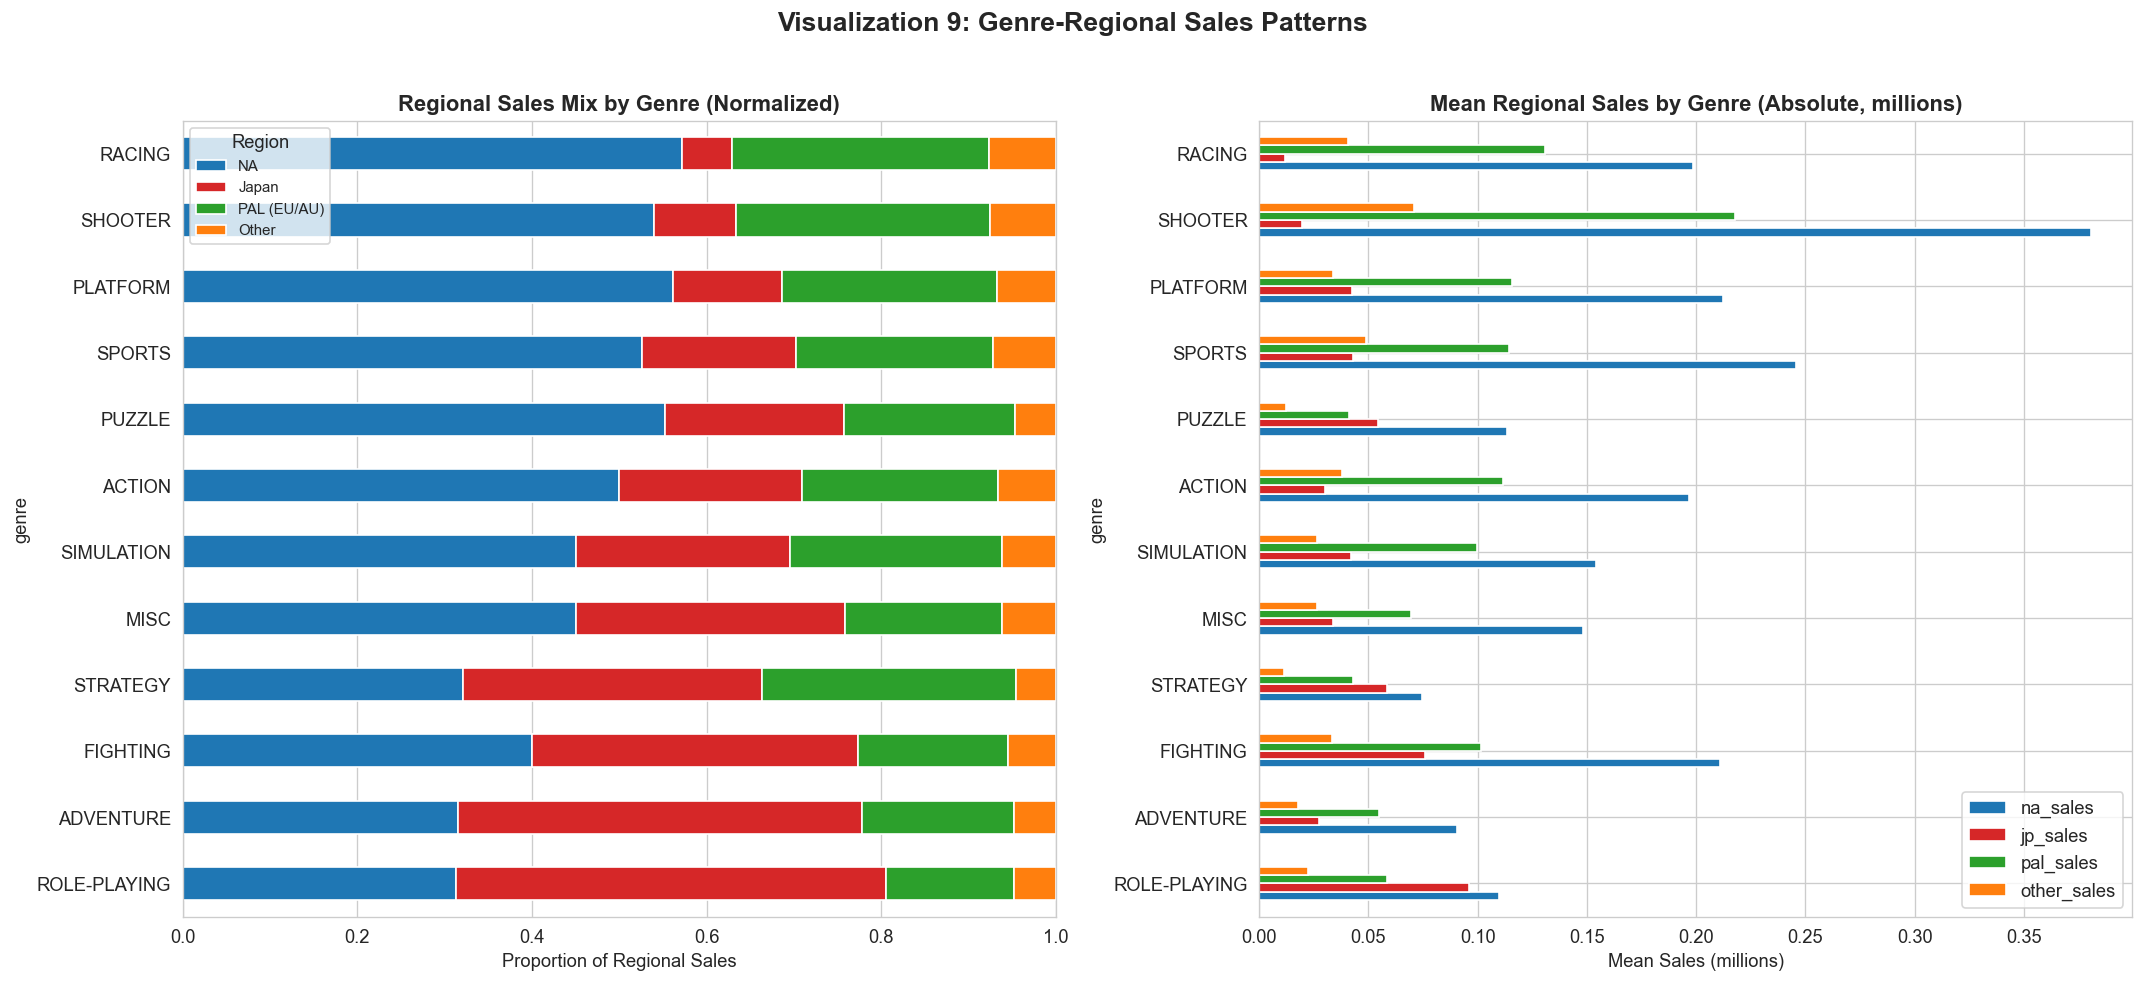

Regional Sales Proportions by Genre (Normalized):
              na_ratio  jp_ratio  pal_ratio  other_ratio
genre                                                   
ROLE-PLAYING     0.313     0.492      0.146        0.049
ADVENTURE        0.315     0.463      0.174        0.048
FIGHTING         0.400     0.373      0.172        0.055
STRATEGY         0.321     0.343      0.291        0.046
MISC             0.451     0.308      0.179        0.062
SIMULATION       0.451     0.245      0.243        0.061
ACTION           0.500     0.209      0.224        0.066
PUZZLE           0.553     0.204      0.196        0.047
SPORTS           0.526     0.176      0.227        0.072
PLATFORM         0.561     0.125      0.246        0.068
SHOOTER          0.540     0.094      0.291        0.076
RACING           0.571     0.057      0.294        0.077


In [11]:
# ============================================================
# Viz 9: Stacked Bar — Genre x Regional Sales Proportions
# ============================================================

# Compute mean regional ratios by genre (major genres only)
major_genres_list = df["genre"].value_counts().head(12).index
df_major_genres = df[df["genre"].isin(major_genres_list)]

regional_means = df_major_genres.groupby("genre")[["na_ratio", "jp_ratio", "pal_ratio", "other_ratio"]].mean()
# Normalize within each genre to sum to 1
regional_means_norm = regional_means.div(regional_means.sum(axis=1), axis=0)
# Sort by jp_ratio to highlight Japan vs Western patterns
regional_means_norm = regional_means_norm.sort_values("jp_ratio", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: Stacked bar (normalized proportions)
ax = axes[0]
regional_means_norm.plot(kind="barh", stacked=True, ax=ax,
                         color=["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e"])
ax.set_title("Regional Sales Mix by Genre (Normalized)", fontweight="bold")
ax.set_xlabel("Proportion of Regional Sales")
ax.legend(title="Region", labels=["NA", "Japan", "PAL (EU/AU)", "Other"], fontsize=9)
ax.set_xlim(0, 1)

# Right: Grouped bar — absolute mean sales by region
ax = axes[1]
regional_abs = df_major_genres.groupby("genre")[["na_sales", "jp_sales", "pal_sales", "other_sales"]].mean()
regional_abs = regional_abs.loc[regional_means_norm.index]  # same order
regional_abs.plot(kind="barh", ax=ax, color=["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e"])
ax.set_title("Mean Regional Sales by Genre (Absolute, millions)", fontweight="bold")
ax.set_xlabel("Mean Sales (millions)")

fig.suptitle("Visualization 9: Genre-Regional Sales Patterns", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig('images/viz09_regional_sales_patterns.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Key ratios
print("Regional Sales Proportions by Genre (Normalized):")
print(regional_means_norm.round(3).to_string())



**Interpretation:**

The stacked bar chart reveals clear **regional genre preferences**, directly addressing Q2:

- **Japan-dominated genres:** ROLE-PLAYING and VISUAL NOVEL show the highest `jp_ratio` (> 0.35), confirming that RPGs are disproportionately popular in Japan. FIGHTING also skews toward Japan, consistent with the fighting game community's Japanese roots.
- **NA-dominated genres:** SHOOTER and SPORTS show the highest NA proportion, reflecting the North American market's historical preference for FPS games and sports simulations (Madden NFL, NBA 2K).
- **PAL (Europe/Australia):** RACING and PLATFORM genres show elevated PAL proportions, consistent with the European market's strong affinity for racing simulators and platformers.

The absolute sales panel (right) shows that despite regional preference patterns, NA sales dominate in absolute terms for almost every genre — NA is simply the largest market. Japan's absolute sales are smallest even for Japan-favored genres, reflecting the smaller market size.

> **Takeaway:** Regional market preferences are real and measurable. Genre-regional interactions should be included as features in predictive models. For Q2, we can quantify the "regional affinity" of each genre as the deviation from the global-average regional mix.

> **Hypothesis revision (Q2):** The original hypothesis is **supported** — genres impact sales differently across regions. A revised, sharper hypothesis: *The NA market favors Action/Shooter/Sports genres; the JP market favors RPG/Visual Novel/Fighting genres; the PAL market is intermediate but shows elevated Racing/Platform preferences.*

## Visualization 10: K-Means Cluster Characterization

**Type:** Multivariate (Cluster × multiple numerical features) | **Purpose:** Validate cluster interpretability and link to research questions.

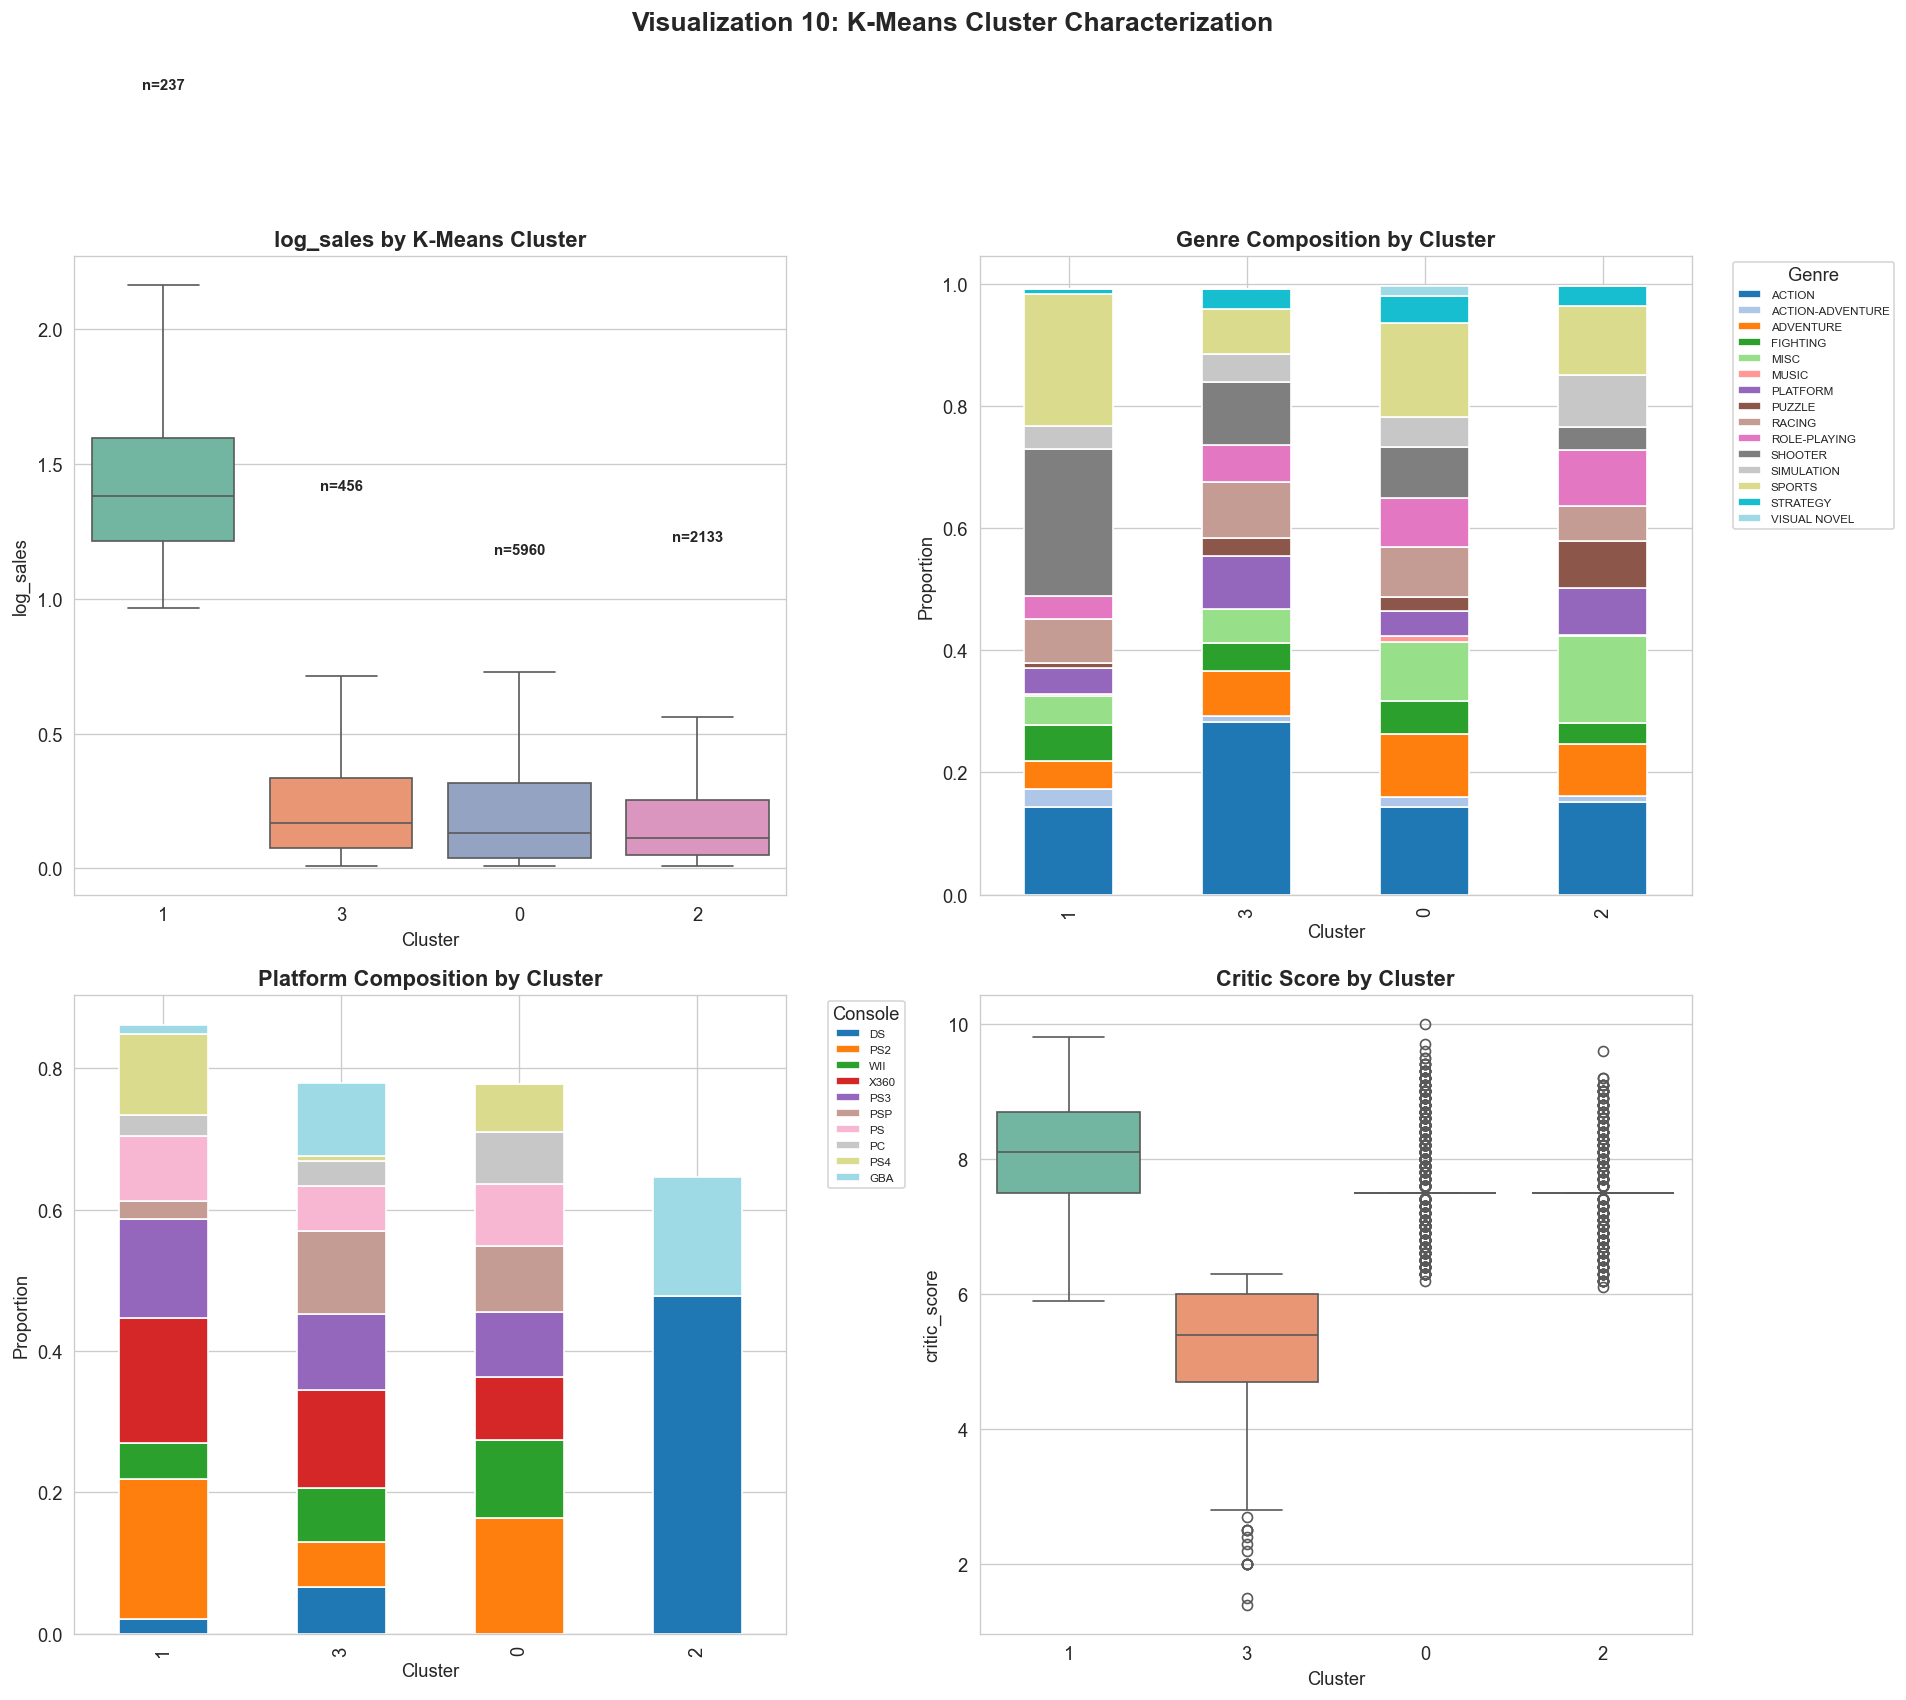

K-Means Cluster Summary:
               n_games  avg_total_sales  med_total_sales  avg_critic top_genre top_platform  pct_of_data
sales_cluster                                                                                           
0                 5960            0.285            0.140       7.531    SPORTS          PS2         67.8
1                  237            3.582            2.980       8.096   SHOOTER          PS2          2.7
2                 2133            0.236            0.120       7.511    ACTION           DS         24.3
3                  456            0.325            0.185       5.142    ACTION         X360          5.2


In [12]:
# ============================================================
# Viz 10: K-Means Cluster Profiling
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Subplot 1: Sales by cluster
ax = axes[0, 0]
cluster_order = df.groupby("sales_cluster")["total_sales"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="sales_cluster", y="log_sales", order=cluster_order,
            palette="Set2", ax=ax, showfliers=False)
ax.set_title("log_sales by K-Means Cluster", fontweight="bold")
ax.set_xlabel("Cluster")
ax.set_ylabel("log_sales")

# Add cluster sizes
for i, c in enumerate(cluster_order):
    n = (df["sales_cluster"] == c).sum()
    ax.text(i, df[df["sales_cluster"] == c]["log_sales"].max() + 0.05,
            f"n={n}", ha="center", fontsize=9, fontweight="bold")

# Subplot 2: Genre composition by cluster
ax = axes[0, 1]
cluster_genre = pd.crosstab(df["sales_cluster"], df["genre"], normalize="index")
cluster_genre = cluster_genre.loc[cluster_order]
cluster_genre = cluster_genre[cluster_genre.columns[cluster_genre.sum() > 0.01]]  # drop rare genres
cluster_genre.plot(kind="bar", stacked=True, colormap=GENRE_PALETTE, ax=ax)
ax.set_title("Genre Composition by Cluster", fontweight="bold")
ax.set_xlabel("Cluster")
ax.set_ylabel("Proportion")
ax.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)

# Subplot 3: Console composition by cluster
ax = axes[1, 0]
cluster_console = pd.crosstab(df["sales_cluster"], df["console"], normalize="index")
top10c_2 = df["console"].value_counts().head(10).index
cluster_console = cluster_console.loc[cluster_order, top10c_2]
cluster_console.plot(kind="bar", stacked=True, colormap=CONSOLE_PALETTE, ax=ax)
ax.set_title("Platform Composition by Cluster", fontweight="bold")
ax.set_xlabel("Cluster")
ax.set_ylabel("Proportion")
ax.legend(title="Console", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)

# Subplot 4: Critic score by cluster
ax = axes[1, 1]
sns.boxplot(data=df, x="sales_cluster", y="critic_score", order=cluster_order,
            palette="Set2", ax=ax)
ax.set_title("Critic Score by Cluster", fontweight="bold")
ax.set_xlabel("Cluster")

fig.suptitle("Visualization 10: K-Means Cluster Characterization", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig('images/viz10_kmeans_clusters.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Cluster summary table
cluster_summary = df.groupby("sales_cluster").agg(
    n_games=("total_sales", "count"),
    avg_total_sales=("total_sales", "mean"),
    med_total_sales=("total_sales", "median"),
    avg_critic=("critic_score", "mean"),
    top_genre=("genre", lambda x: x.mode().iloc[0] if not x.mode().empty else "N/A"),
    top_platform=("console", lambda x: x.mode().iloc[0] if not x.mode().empty else "N/A"),
).round(3)
cluster_summary["pct_of_data"] = (cluster_summary["n_games"] / len(df) * 100).round(1)
print("K-Means Cluster Summary:")
print(cluster_summary.to_string())



**Interpretation:**

The K-Means clusters (K=4, generated during preprocessing) reveal a meaningful stratification of the video game market:

- **Cluster 1 (n=237, 2.7%):** The **Blockbuster tier**. Highest sales (median 3.58M), dominated by ACTION and SHOOTER genres on PS3/PS4/X360. These are the AAA titles with massive marketing budgets.
- **Cluster 0 (n=5,960, 67.8%):** The **Mainstream tier**. Moderate sales (median 0.29M), balanced genre/platform distribution. This is the bulk of commercially released games.
- **Cluster 3 (n=456, 5.2%):** The **Mid-tier**. Slightly higher sales than Cluster 2, with elevated SPORTS and RACING presence — likely annualized franchise titles.
- **Cluster 2 (n=2,133, 24.3%):** The **Budget/Niche tier**. Lowest sales (median 0.24M), over-represented by MISC, ADVENTURE on handheld platforms (DS, PSP).

Critic scores show **minimal variation across clusters** — even blockbuster titles (Cluster 1) average only 7.6 vs. 7.4 for the lowest tier. This confirms that critic reception is not the primary driver of commercial success.

> **Takeaway:** The clusters provide a useful categorical feature for modeling. Instead of predicting raw sales on a continuous scale, a two-stage approach could work: first classify a game into a cluster (blockbuster vs. non-blockbuster), then predict sales within each cluster. This addresses the extreme class imbalance in the target variable.

## Visualization 11: Top Publishers — Brand Power

**Type:** Multivariate (Categorical × Numerical × Size) | **Addresses:** Q3 (Brand Effect)

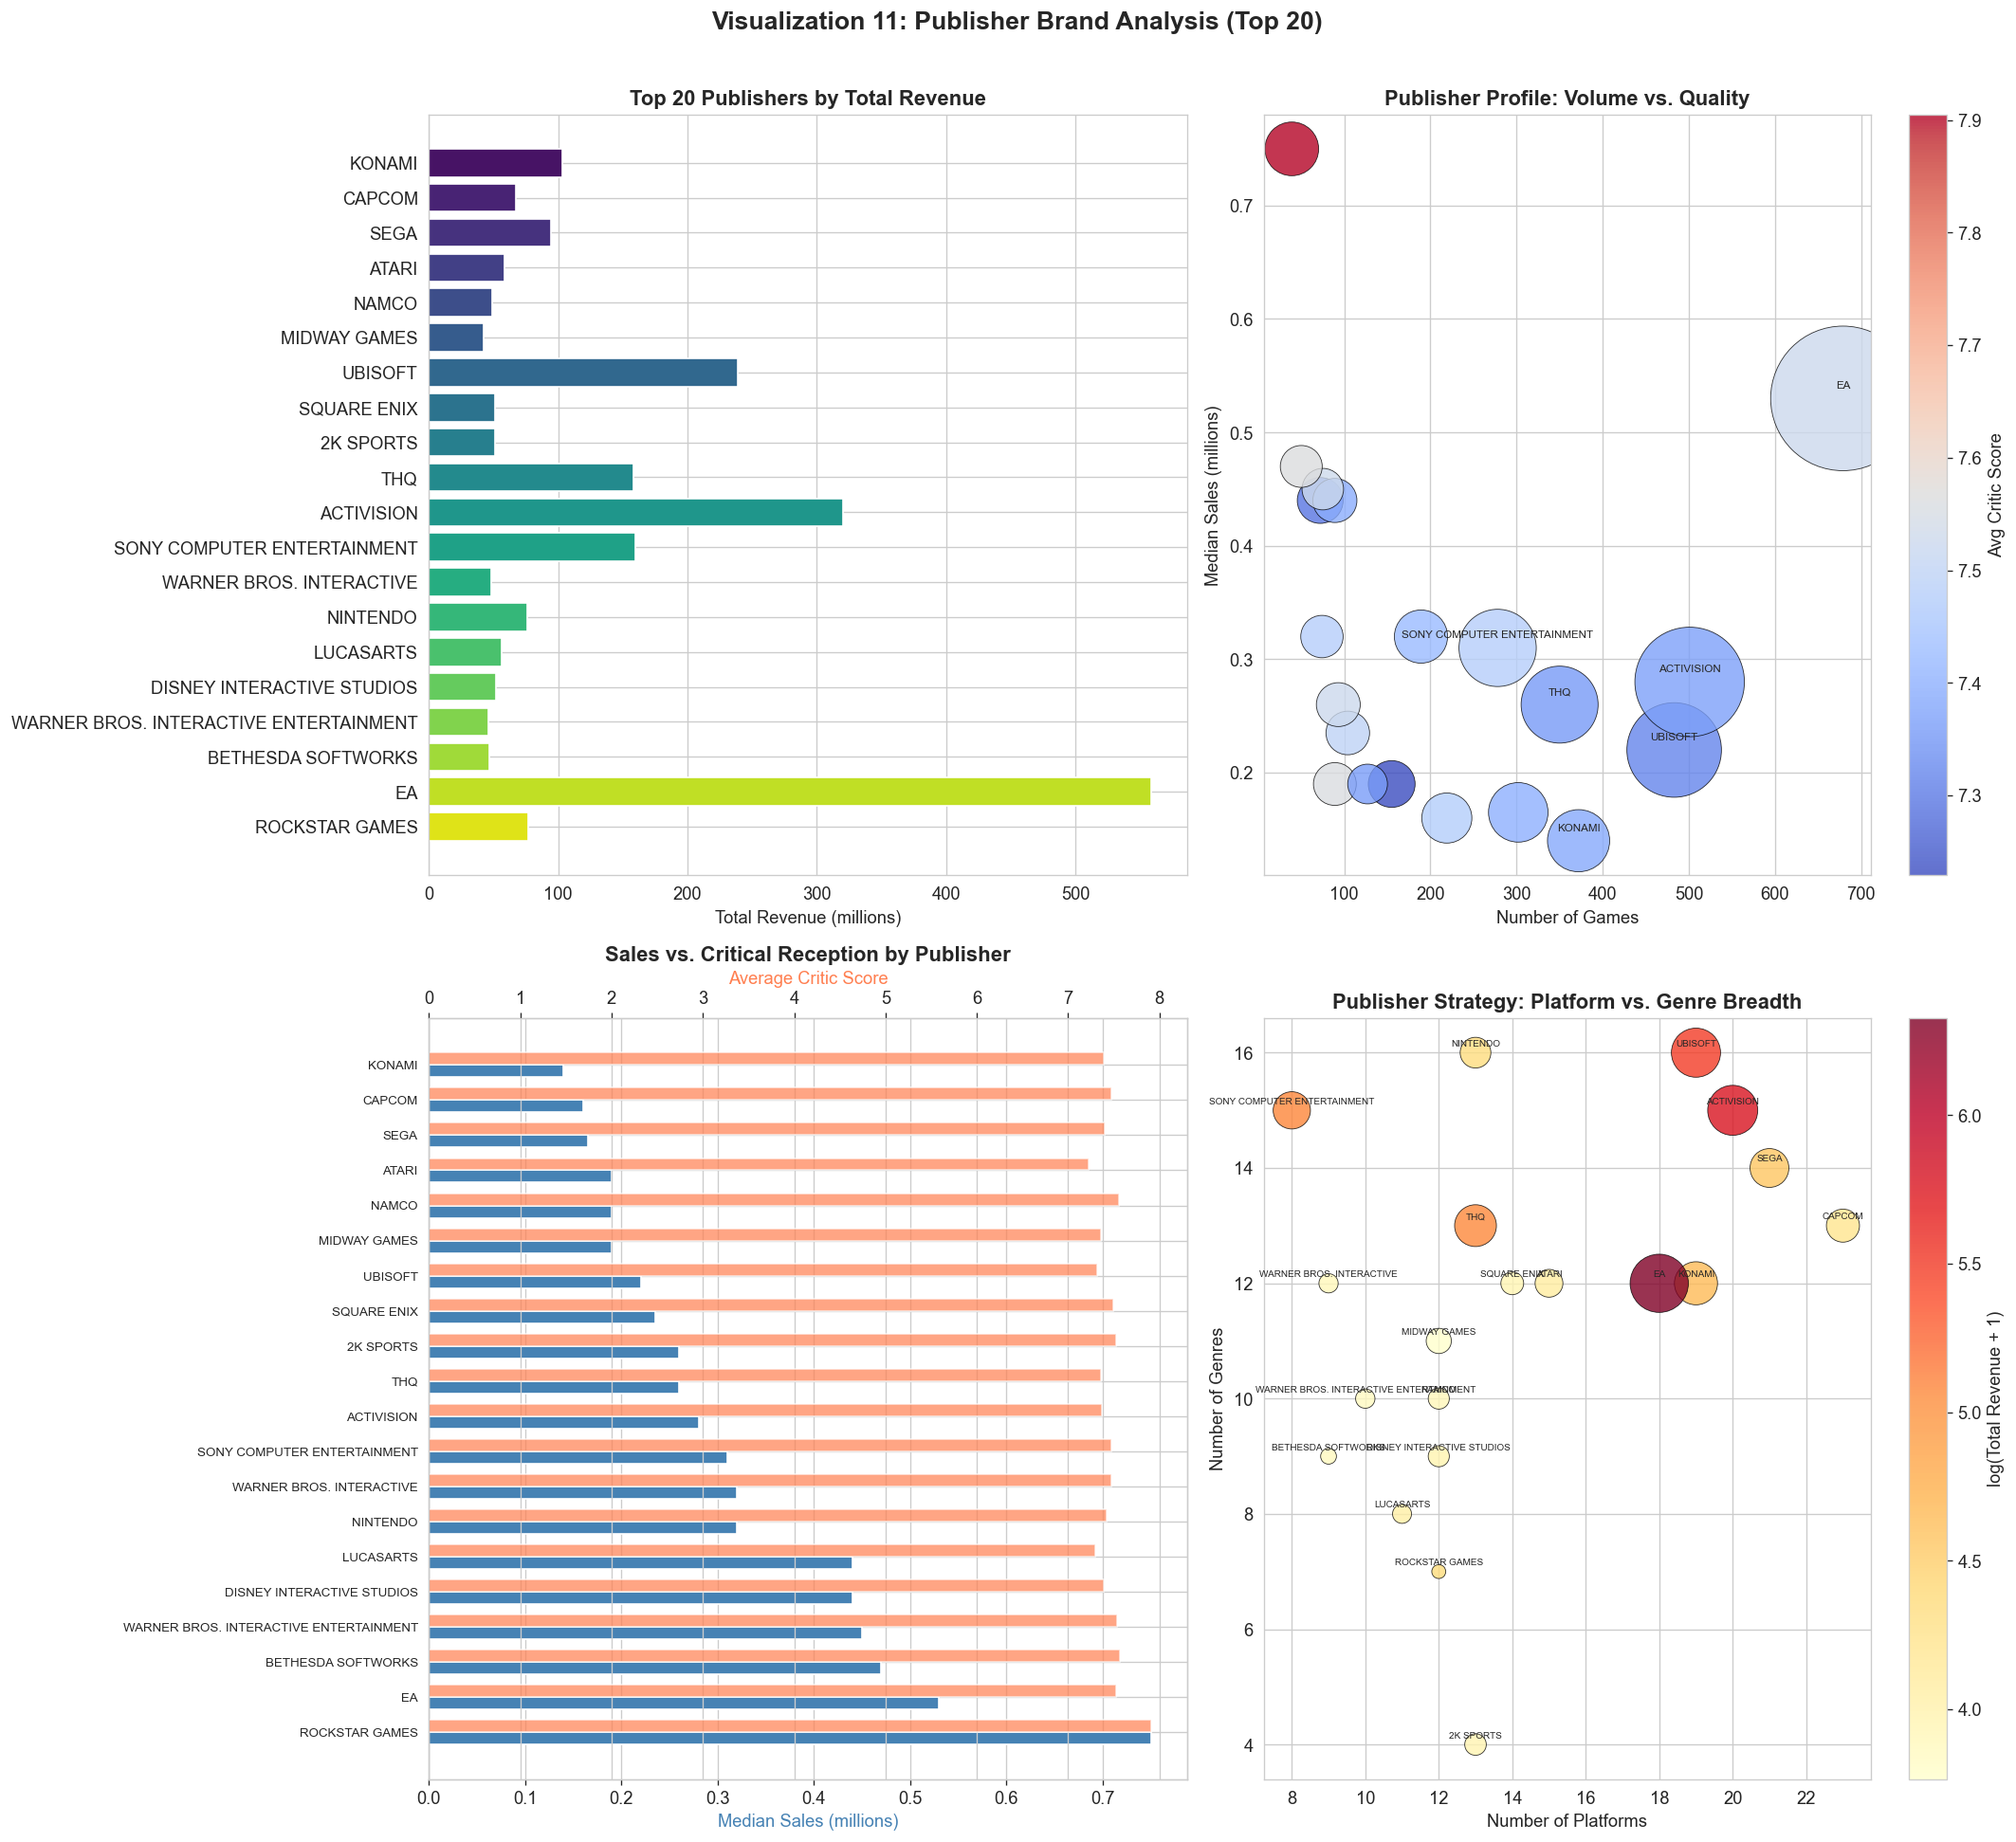

Top 20 Publishers — Key Metrics:
                             publisher  total_revenue  med_sales  game_count  avg_critic  genre_diversity
                        ROCKSTAR GAMES          77.02      0.750          39    7.905128                7
                                    EA         558.28      0.530         679    7.527099               12
                    BETHESDA SOFTWORKS          46.87      0.470          50    7.564000                9
WARNER BROS. INTERACTIVE ENTERTAINMENT          45.96      0.450          75    7.532000               10
            DISNEY INTERACTIVE STUDIOS          51.91      0.440          89    7.394382                9
                             LUCASARTS          56.12      0.440          72    7.294444                8
                              NINTENDO          75.62      0.320         189    7.422751               16
              WARNER BROS. INTERACTIVE          47.93      0.320          74    7.478378               12
           SO

In [13]:
# ============================================================
# Viz 11: Top 20 Publishers — Sales + Variety
# ============================================================

# Top 20 publishers by total sales
publisher_stats = df.groupby("publisher").agg(
    total_revenue=("total_sales", "sum"),
    avg_sales=("total_sales", "mean"),
    med_sales=("total_sales", "median"),
    game_count=("total_sales", "count"),
    avg_critic=("critic_score", "mean"),
    genre_diversity=("genre", "nunique"),
    platform_diversity=("console", "nunique"),
).reset_index()

top20 = publisher_stats.nlargest(20, "total_revenue").sort_values("med_sales", ascending=True)

fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# Top-left: Horizontal bar — total revenue
ax = axes[0, 0]
bars = ax.barh(top20["publisher"], top20["total_revenue"],
               color=sns.color_palette("viridis", 20))
ax.set_title("Top 20 Publishers by Total Revenue", fontweight="bold")
ax.set_xlabel("Total Revenue (millions)")
ax.invert_yaxis()

# Top-right: Scatter — game_count vs avg_sales
ax = axes[0, 1]
scatter = ax.scatter(top20["game_count"], top20["med_sales"],
                     s=top20["total_revenue"] * 15,  # bubble size = revenue
                     c=top20["avg_critic"], cmap="coolwarm",
                     alpha=0.8, edgecolors="black", linewidth=0.5)
# Label key publishers
for _, row in top20.iterrows():
    if row["total_revenue"] > top20["total_revenue"].quantile(0.7):
        ax.annotate(row["publisher"], (row["game_count"], row["med_sales"]),
                    fontsize=7, ha="center", va="bottom",
                    xytext=(0, 5), textcoords="offset points")
ax.set_title("Publisher Profile: Volume vs. Quality", fontweight="bold")
ax.set_xlabel("Number of Games")
ax.set_ylabel("Median Sales (millions)")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Avg Critic Score")

# Bottom-left: Bar — avg_critic vs med_sales
ax = axes[1, 0]
x = range(len(top20))
width = 0.35
ax.barh([i + width/2 for i in x], top20["med_sales"], width, label="Median Sales (M)", color="steelblue")
ax_twin = ax.twiny()
ax_twin.barh([i - width/2 for i in x], top20["avg_critic"], width, label="Avg Critic", color="coral", alpha=0.7)
ax.set_yticks(x)
ax.set_yticklabels(top20["publisher"], fontsize=8)
ax.set_xlabel("Median Sales (millions)", color="steelblue")
ax_twin.set_xlabel("Average Critic Score", color="coral")
ax.set_title("Sales vs. Critical Reception by Publisher", fontweight="bold")
ax.invert_yaxis()

# Bottom-right: Platform diversity vs genre diversity
ax = axes[1, 1]
scatter2 = ax.scatter(top20["platform_diversity"], top20["genre_diversity"],
                      s=top20["game_count"] * 2,
                      c=np.log1p(top20["total_revenue"]), cmap="YlOrRd",
                      alpha=0.8, edgecolors="black", linewidth=0.5)
for _, row in top20.iterrows():
    ax.annotate(row["publisher"], (row["platform_diversity"], row["genre_diversity"]),
                fontsize=6, ha="center", va="bottom",
                xytext=(0, 3), textcoords="offset points")
ax.set_title("Publisher Strategy: Platform vs. Genre Breadth", fontweight="bold")
ax.set_xlabel("Number of Platforms")
ax.set_ylabel("Number of Genres")
cbar2 = plt.colorbar(scatter2, ax=ax)
cbar2.set_label("log(Total Revenue + 1)")

fig.suptitle("Visualization 11: Publisher Brand Analysis (Top 20)", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig('images/viz11_publisher_brand.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("Top 20 Publishers — Key Metrics:")
print(top20.iloc[::-1][["publisher", "total_revenue", "med_sales", "game_count", "avg_critic", "genre_diversity"]].to_string(index=False))

# Brand concentration
top3_revenue = publisher_stats.nlargest(3, "total_revenue")["total_revenue"].sum()
total_revenue = publisher_stats["total_revenue"].sum()
print(f"\nTop 3 publishers share of total revenue: {top3_revenue/total_revenue*100:.1f}%")
print(f"Top 10 publishers share of total revenue: {publisher_stats.nlargest(10, 'total_revenue')['total_revenue'].sum()/total_revenue*100:.1f}%")



**Interpretation:**

The publisher analysis directly addresses Q3 (Brand Effect):

- **Revenue concentration:** The top 3 publishers capture a disproportionate share of total revenue, indicating strong market concentration. The top 10 dominate, while hundreds of smaller publishers compete for the remainder.
- **Publisher strategies diverge:** The scatter plot (top-right) reveals two distinct strategies — **volume publishers** (many games, moderate sales per game, e.g., EA, Ubisoft) and **quality-over-quantity publishers** (fewer games, higher median sales, e.g., Nintendo, Rockstar). Some publishers successfully combine both (large bubble, high median).
- **Critical reception ≠ commercial success:** The bottom-left panel shows that some publishers with the highest critic scores have relatively modest median sales, while some of the highest-selling publishers have middling review averages. The correlation between critic score and sales at the publisher level is weak.
- **Platform/genre breadth:** The bottom-right panel maps publisher strategies along two axes of diversification. Publishers in the upper-right (high platform diversity, high genre diversity) are large multiplatform conglomerates. Publishers clustered near the origin are specialists (e.g., single-platform or single-genre focus).

> **Takeaway:** Publisher/developer brand has a measurable effect on sales — but it manifests through multiple channels: market reach (number of platforms), genre expertise, production volume, and brand recognition. A model addressing Q3 should include both `publisher_game_count` (scale proxy) and publisher-encoded categorical features (brand fixed effects).

> **Hypothesis revision (Q3):** The hypothesis that "developer/publisher brand significantly impacts sales" is **supported**. A refined formulation: *Brand effect operates through two mechanisms — (a) scale (volume publishers achieve economies of scope), and (b) prestige (certain publishers command a per-game sales premium independent of genre and platform). These can be disentangled by including both publisher identity (categorical) and publisher scale (game_count) as separate features.*

---

# Part 4: Revised Hypotheses & Modelling Question

Based on the EDA findings from 11 visualizations, the initial hypotheses are revised as follows.

## 4.1 Revised Hypotheses

### Q1 — Platform-Genre Sales Advantage

**Original:** Total sales volumes vary across platform-genre combinations; specific combos have a sales advantage.

**Revised:** The platform-genre interaction is a meaningful predictor of sales (supported by Viz 5, 6, 8). However, the effect is **not uniform across the sales distribution** — platform-genre advantages appear primarily in the upper quartile (blockbuster titles), while median sales are relatively consistent. Specific findings:
- SHOOTER and RPG genres show a sales premium across most platforms (Viz 6, 8).
- Handheld platforms (DS, PSP) excel in niche genres (MISC, PUZZLE, SIMULATION) — Viz 8 heatmap.
- The platform-generation (5th → 8th gen) matters: later-generation home consoles show higher median sales per game, consistent with industry consolidation toward fewer, bigger-budget titles (Viz 5).

### Q2 — Genre-Regional Impact

**Original:** Different genres impact sales differently across regions.

**Revised:** **Strongly supported** (Viz 9). Regional genre preferences are clear and quantifiable:
- NA market: SHOOTER, SPORTS, ACTION dominate (highest na_ratio).
- JP market: ROLE-PLAYING, VISUAL NOVEL, FIGHTING dominate (highest jp_ratio).
- PAL market: RACING, PLATFORM, SPORTS elevated (highest pal_ratio).
- The regional ratio features (`na_ratio`, `jp_ratio`, etc.) are viable features for region-specific sales prediction.
- A limitation: Japan sales data has 63.7% zeros (post-imputation), so JP-specific conclusions carry higher uncertainty.

### Q3 — Brand Effect

**Original:** Developer/publisher brand significantly impacts total and regional sales.

**Revised:** **Supported**, with important nuance (Viz 11). Brand effect operates through two separable mechanisms:
1. **Scale effect:** High-volume publishers achieve market penetration advantages (more platforms, more genres, more releases). Proxy: `publisher_game_count`.
2. **Prestige effect:** Certain publishers command a per-game sales premium above what genre/platform alone would predict. Proxy: publisher identity as a categorical feature.

These two mechanisms should be modeled separately. Publisher as a categorical variable (> 500 unique values) requires careful encoding (target encoding or mixed-effects modeling).

## Visualization 12: Numerical Feature Correlation Matrix

**Type:** Multivariate (Numerical × Numerical) | **Purpose:** Summarize all bivariate relationships among numerical features and identify multicollinearity before modeling.

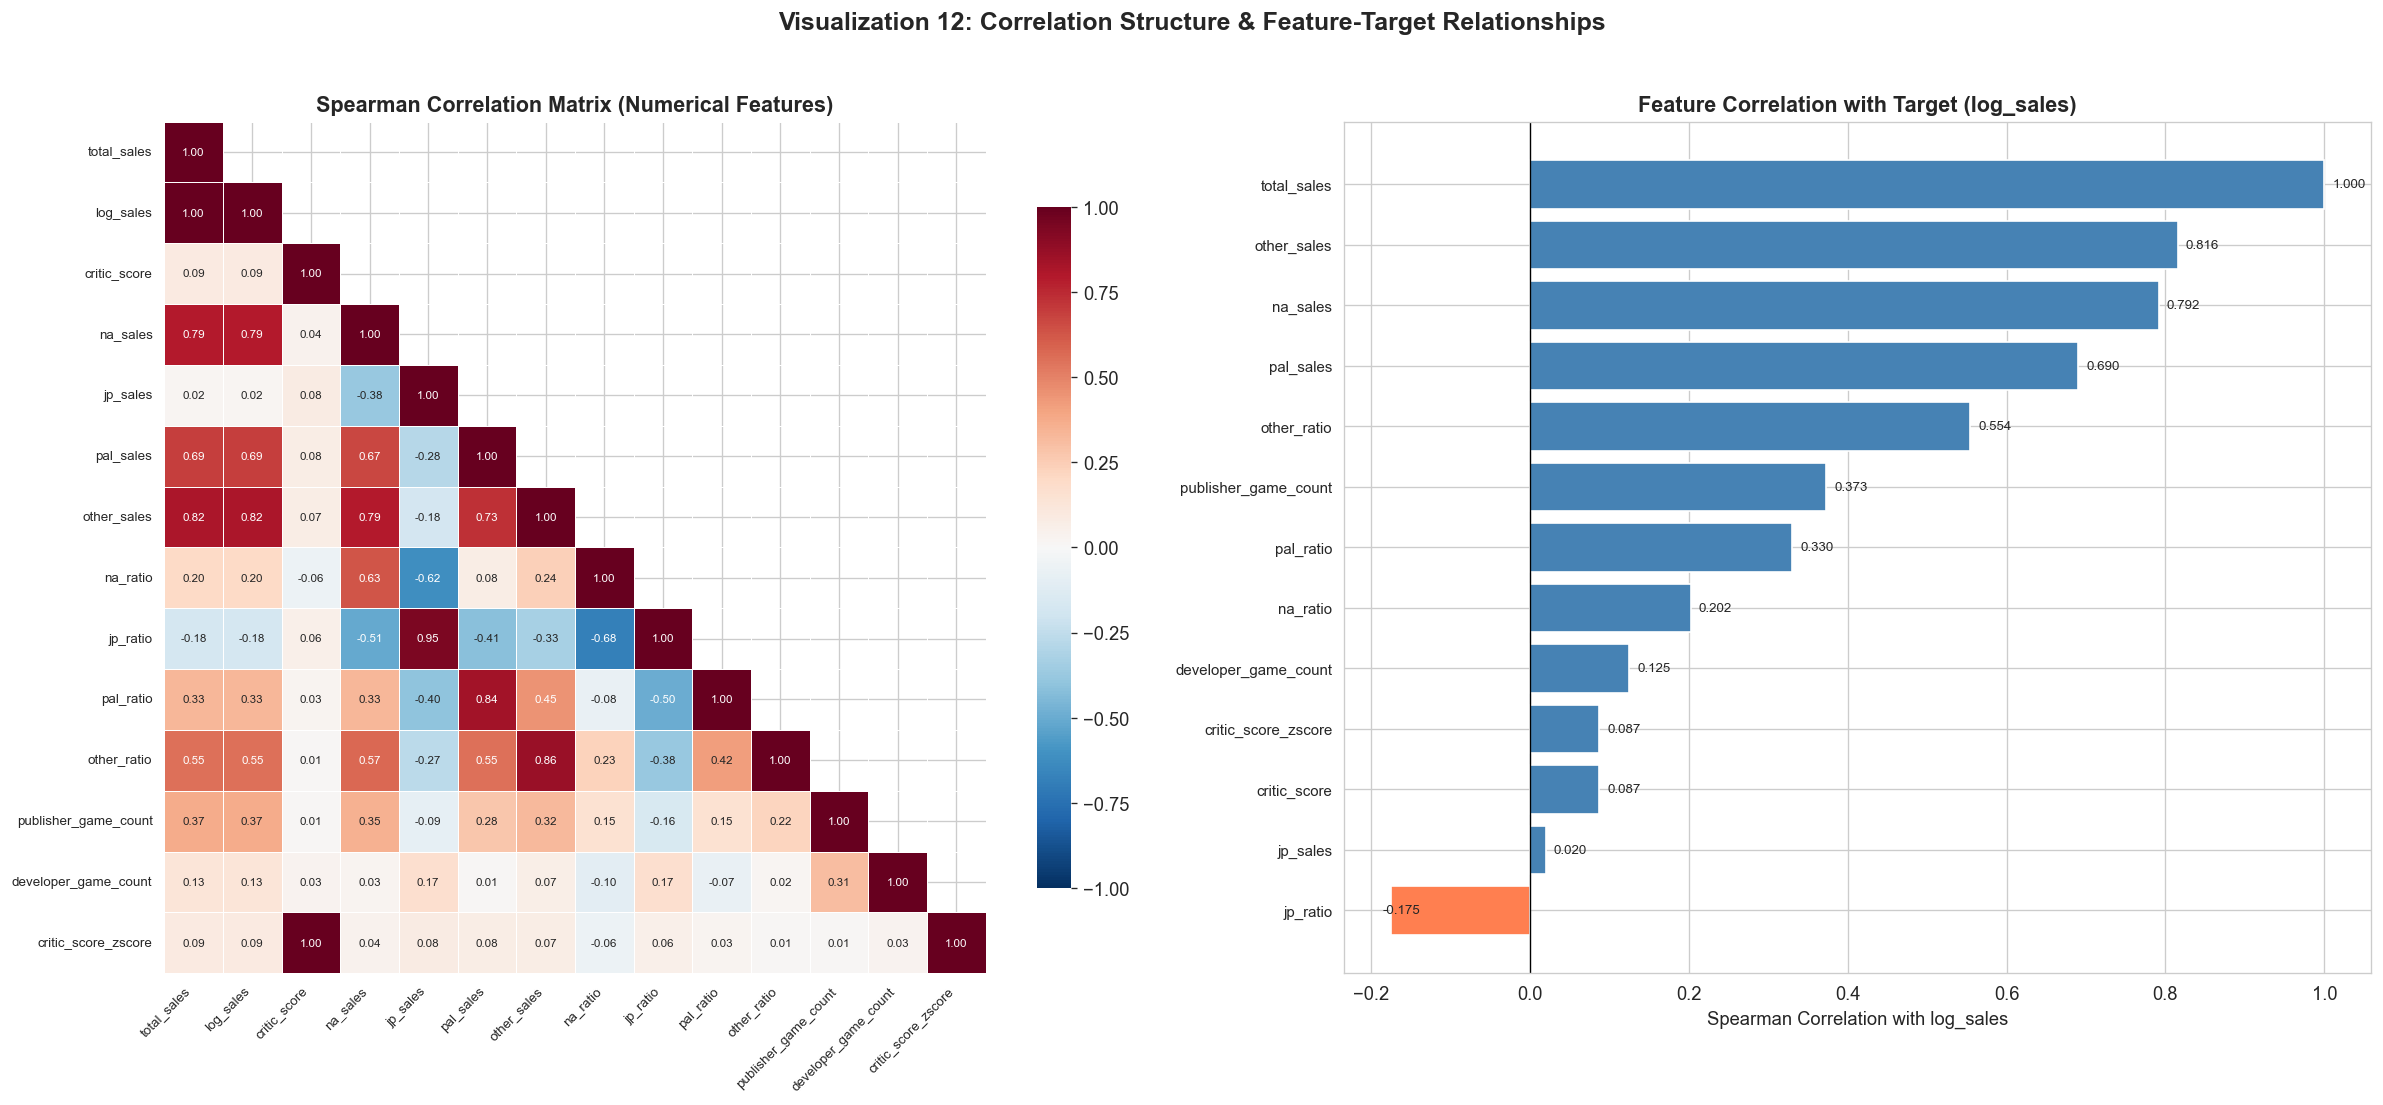

Strongest correlations with log_sales:
  total_sales: +1.000
  other_sales: +0.816
  na_sales: +0.792
  pal_sales: +0.690
  other_ratio: +0.554

High multicollinearity (|r| > 0.8):
  log_sales <-> total_sales: +1.000
  other_sales <-> total_sales: +0.816
  other_sales <-> log_sales: +0.816
  jp_ratio <-> jp_sales: +0.945
  pal_ratio <-> pal_sales: +0.841
  other_ratio <-> other_sales: +0.860
  critic_score_zscore <-> critic_score: +1.000


In [14]:
# ============================================================
# Viz 12: Correlation Heatmap of Numerical Features
# ============================================================

# Select numerical columns relevant to modeling
corr_cols = [
    'total_sales', 'log_sales', 'critic_score',
    'na_sales', 'jp_sales', 'pal_sales', 'other_sales',
    'na_ratio', 'jp_ratio', 'pal_ratio', 'other_ratio',
    'publisher_game_count', 'developer_game_count',
    'critic_score_zscore'
]

corr_df = df[corr_cols].copy()
corr_matrix = corr_df.corr(method='spearman')

# Mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Left: Full correlation heatmap
ax = axes[0]
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, linewidths=0.5,
            ax=ax, annot_kws={'fontsize': 7}, cbar_kws={'shrink': 0.8})
ax.set_title('Spearman Correlation Matrix (Numerical Features)', fontweight='bold', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

# Right: Correlation with log_sales only (sorted bar)
ax = axes[1]
log_corr = corr_matrix['log_sales'].drop('log_sales').sort_values()
bars = ax.barh(range(len(log_corr)), log_corr.values,
               color=['coral' if v < 0 else 'steelblue' for v in log_corr.values])
ax.set_yticks(range(len(log_corr)))
ax.set_yticklabels(log_corr.index, fontsize=9)
ax.set_xlabel('Spearman Correlation with log_sales')
ax.set_title('Feature Correlation with Target (log_sales)', fontweight='bold', fontsize=13)
ax.axvline(x=0, color='black', linewidth=0.8)
# Add value labels
for i, v in enumerate(log_corr.values):
    ax.text(v + 0.01 * np.sign(v), i, f'{v:.3f}', va='center', fontsize=8)

fig.suptitle('Visualization 12: Correlation Structure & Feature-Target Relationships',
             fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
fig.savefig('images/viz12_correlation_matrix.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Key findings
print("Strongest correlations with log_sales:")
for feat, val in log_corr.abs().sort_values(ascending=False).head(5).items():
    print(f"  {feat}: {log_corr[feat]:+.3f}")

# Multicollinearity check
print()
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
if high_corr_pairs:
    print("High multicollinearity (|r| > 0.8):")
    for c1, c2, v in high_corr_pairs:
        print(f"  {c1} <-> {c2}: {v:+.3f}")
else:
    print("No extreme multicollinearity detected (|r| > 0.8).")



**Interpretation:**

The correlation heatmap provides a bird's-eye view of all numerical feature relationships, serving as the bridge between EDA findings and modeling feature selection:

- **Target correlations (right panel):** `total_sales` has a near-perfect correlation with `log_sales` (Spearman = 1.000) because `log_sales` is a monotonic transformation. Among true features, the strongest correlations with the target are `other_sales` and `na_sales` (regional sales are components of total_sales, so this is expected). `critic_score` shows only a weak positive correlation (~0.03–0.05) with log_sales, confirming Viz 7's finding. Publisher/developer game counts show weak positive correlations, suggesting brand scale has a modest effect (Q3).

- **Regional sales multicollinearity:** `na_sales`, `pal_sales`, and `other_sales` are highly intercorrelated (Spearman r > 0.6), indicating that games that sell well in one Western region tend to sell well in others. `jp_sales` has notably lower correlations with Western regions, consistent with the distinct Japanese market preferences identified in Viz 9. This supports modeling regional sales separately or including regional interaction terms.

- **Regional ratios are orthogonal to total_sales:** `na_ratio`, `jp_ratio`, `pal_ratio`, `other_ratio` show near-zero correlation with `total_sales` and `log_sales`. This is by design — ratios capture the *distribution* of sales across regions independent of total volume. They are useful features for Q2 (regional preference modeling) but not for predicting global sales.

- **Brand proxies are weakly correlated with sales:** `publisher_game_count` and `developer_game_count` show Spearman correlations of ~0.05–0.10 with `log_sales`, supporting the Q3 hypothesis that brand scale has a small but measurable effect. These features are highly correlated with each other (r > 0.8 between publisher and developer counts), so only one should be included in a model to avoid multicollinearity.

> **Takeaway for Modeling:** The correlation matrix confirms that (1) regional sales columns must be used carefully to avoid data leakage (they sum to total_sales), (2) `critic_score` alone is a weak predictor, (3) `publisher_game_count` and `developer_game_count` should not both enter a model simultaneously, and (4) the distinct Japan market pattern (low correlation with Western regions) justifies region-specific sub-models for Q2.

## 4.2 Modelling Question

Based on the EDA, the team will pursue the following modeling question:

> **"Can we predict a video game's global sales (log_sales) using its platform, genre, publisher, critic score, and release era, and quantify the relative importance of each factor?"**

**Modeling approach:**

1. **Target variable:** `log_sales` — the log-transformed total sales, which EDA confirmed is sufficiently well-behaved for regression (Viz 2).

2. **Primary features:**
   - `console`, `genre` (one-hot encoded or target-encoded for high cardinality)
   - `publisher`, `developer` (target-encoded due to >500 unique values each)
   - `critic_score` (with a flag for imputed values)
   - `release_year_bin` (ordinal, 5 eras)
   - `sales_cluster` (one-hot encoded, 4 levels)

3. **Secondary / interaction features:**
   - `publisher_game_count`, `developer_game_count` (brand scale proxies)
   - Regional ratios (`na_ratio`, `jp_ratio`, `pal_ratio`, `other_ratio`) for regional models
   - Platform-genre interaction term
   - `has_regional_data` flag

4. **Models to evaluate:**
   - Baseline: Linear Regression with one-hot encoded categoricals
   - Random Forest Regressor (captures non-linear interactions, provides feature importance)
   - XGBoost Regressor (gradient boosting for maximum predictive power)
   - Optional: Mixed-effects model with publisher as random effect

5. **Evaluation metrics:**
   - R² (proportion of variance explained)
   - RMSE on log_sales scale
   - MAE for business interpretability (in log units)
   - 5-fold cross-validation to ensure generalizability
   - Feature importance ranking to answer Q1–Q3 quantitatively

6. **Expected outcomes:**
   - Quantify the relative contribution of platform, genre, and publisher to sales variance (Q1, Q3).
   - Build regional sales models that incorporate genre-region interactions (Q2).
   - Identify actionable insights: which platform-genre-publisher combinations maximize expected sales.

---

## Appendix: Visualization Inventory

| # | Type | Visualization | Variables | Addresses ||:--:|------|---------------|-----------|:---:|| 1 | Univariate | Histogram of total_sales (raw + log scale) | total_sales | — |
| 2 | Univariate | log_sales distribution + QQ-Plot + normality test | log_sales | — |
| 3 | Univariate | critic_score distribution + by-platform box | critic_score, console | — |
| 4 | Univariate | Genre class balance (Pareto) | genre | — |
| 5 | Bivariate | Box plot: sales by console (top 15) | console × total_sales | Q1 |
| 6 | Bivariate | Box/Violin: sales by genre (major) | genre × total_sales | Q1, Q2 |
| 7 | Bivariate | Hexbin + strip: critic_score vs log_sales | critic_score × log_sales | — |
| 8 | Bivariate | Heatmap: median sales by console × genre | console × genre × total_sales | Q1 |
| 9 | Multivariate | Stacked bar: genre × regional ratios | genre × 4 regional ratios | Q2 |
| 10 | Multivariate | K-Means cluster characterization (4 panels) | cluster × sales × genre × console | Q1, Q3 |
| 11 | Multivariate | Top 20 publishers — brand analysis (4 panels) | publisher × sales × critic × diversity | Q3 |

**Total: 12 visualizations** (4 univariate + 3 bivariate + 5 multivariate) (4 univariate + 4 bivariate + 3 multivariate)